<a href="https://colab.research.google.com/github/Parisashourmage/Colab-Notebooks/blob/main/Temporal_Causal_GRN_AuditFixed_Colab_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Causal GRN — Audit-Fixed Colab v5

این نسخه برای اجرای کم‌حافظه در Google Colab بازطراحی شده است.

**تغییرات اصلی:**
- به‌جای یک pseudotime مشترک بین چهار محیط، pseudotime به‌صورت جداگانه داخل هر محیط محاسبه می‌شود.
- مدل به‌صورت **joint/shared across environments** آموزش داده می‌شود تا condition modulation واقعاً از چهار محیط مختلف یاد بگیرد.
- GRU روی ترتیب مصنوعی ژن‌ها حذف شده است؛ معماری نسبت به permutation ژن‌ها مناسب‌تر است.
- یک مدل مشترک نگه داشته می‌شود و مدل‌های چهار محیط همزمان در RAM ذخیره نمی‌شوند.
- inference مربوط به Jacobian و ablation فقط برای TFهای candidate انجام می‌شود؛ بنابراین هزینه تقریباً از `G×G` به `TF×G` کاهش می‌یابد.
- candidate space برای Causal-GAT، Correlation و GENIE3 دقیقاً یکسان است.
- GENIE3 با Arboreto اجرا می‌شود؛ Arboreto، GENIE3 را با Random Forest پیاده‌سازی می‌کند و ورودی آن observations × genes است. citeturn3search1turn3search3
- multi-seed به‌صورت sequential اجرا می‌شود تا مدل‌های seedهای مختلف همزمان در RAM نباشند.
- Ablation فقط در صورت فعال‌کردن آن اجرا می‌شود و در فضای candidate یکسان ارزیابی می‌شود.

**نکته علمی:** هیچ کدی نمی‌تواند تضمین کند داور هیچ ایرادی نگیرد. این نسخه ایرادهای مشخصی را که در audit قبلی پیدا شد برطرف می‌کند، ولی causal identification از داده observational به‌تنهایی همچنان قابل ادعای قطعی نیست؛ برای جهت علّی کامل معمولاً فرض‌های اضافی یا داده مداخله‌ای لازم است. citeturn0search12turn0search4

In [1]:

# =========================
# CELL 1 — Install
# =========================
%pip -q install "pandas==2.2.3" "scanpy>=1.10" "anndata>=0.10" seaborn openpyxl scikit-learn
%pip -q install "arboreto==0.1.6" "dask-expr<1.0.0"


In [2]:

# =========================
# CELL 2 — Imports / configuration
# =========================
import os, gc, re, time, random, warnings, math, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

import torch
import torch.nn as nn

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ---------- paths ----------
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

DATA_DIR = Path("/content")
DRIVE_DIR = Path("/content/drive/MyDrive")
OUT_DIR = DRIVE_DIR / "final_grn_results_v5_audit_fixed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- data ----------
CSV_PATH = DATA_DIR / "GSE125162_counts.tsv.gz"
GEO_COUNTS_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE125nnn/"
    "GSE125162/suppl/GSE125162_ALL-fastqTomat0-Counts.tsv.gz"
)
YEASTRACT_PATH = DATA_DIR / "YEASTRACT.csv"

# If you have an independent yeast TF list, put it here.
# One gene/systematic ID per line.
TF_LIST_PATH = DATA_DIR / "S_cerevisiae_TF_list.txt"
ALLOW_ORACLE_TF_FALLBACK = True  # set False for the strictest audit

TARGET_ENVS = ["YPD", "YPDRapa", "YPDDiauxic", "CStarve"]

# ---------- preprocessing ----------
MIN_GENES_PER_CELL = 200
MIN_CELLS_PER_GENE = 3
N_HVG = 500
N_PCS = 30

# ---------- low-memory training ----------
HIDDEN = 32
COND_DIM = 16
LOW_RANK = 8
BATCH_SIZE = 64
TRAIN_MAX_CELLS_PER_ENV = 6000  # equal cap per environment; None = all
INFER_CELL_CHUNK = 32

LR = 1e-3
WEIGHT_DECAY = 1e-5
LAMBDA_SPARSE = 1e-4
TEMPORAL_GAMMA = 5.0

DAG_OUTER_STEPS = 4
EPOCHS_PER_DAG_STEP = 15
DAG_RHO_INIT = 1.0
DAG_RHO_MAX = 1e12
DAG_ALPHA_INIT = 0.0

GRAD_WEIGHT = 0.5
ABLATION_WEIGHT = 0.5

# ---------- robustness ----------
RUN_MULTI_SEED = True
ROBUSTNESS_SEEDS = [42, 52, 62]  # 3 total seeds
# If runtime is too long, use [42, 52].
MULTISEED_ENVS = TARGET_ENVS.copy()

# ---------- ablation ----------
RUN_ABLATION = False
ABLATION_ENV = "YPD"

# ---------- GENIE3 ----------
RUN_GENIE3 = True
GENIE3_MAX_CELLS = 1500
GENIE3_N_ESTIMATORS = 50
GENIE3_N_WORKERS = 1
GENIE3_SEED = 42

print("OUT_DIR:", OUT_DIR)
print("Robustness seeds:", ROBUSTNESS_SEEDS if RUN_MULTI_SEED else [SEED])


DEVICE: cuda
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OUT_DIR: /content/drive/MyDrive/final_grn_results_v5_audit_fixed
Robustness seeds: [42, 52, 62]


In [3]:

# =========================
# CELL 3 — Load GSE125162 and parse environments
# =========================
print("="*70)
print("LOAD GSE125162")
print("="*70)

if not CSV_PATH.exists():
    print("Downloading GSE125162...")
    os.system(f'wget -q "{GEO_COUNTS_URL}" -O "{CSV_PATH}"')

if not CSV_PATH.exists() or CSV_PATH.stat().st_size == 0:
    raise FileNotFoundError("GSE125162 count file was not found.")

df_full = pd.read_csv(CSV_PATH, sep="\t", index_col=0)
print("Raw shape:", df_full.shape)

def looks_like_gene_id(x):
    s = str(x).upper()
    return (
        (s.startswith("Y") and len(s) >= 6)
        or s in {"COX1","COX2","COX3","COB","ATP6","ATP8","ATP9","OLI1","VAR1"}
    )

def detect_counts_orientation(df):
    idx_gene = np.mean([looks_like_gene_id(x) for x in df.index[:min(1000, len(df.index))]])
    col_gene = np.mean([looks_like_gene_id(x) for x in df.columns[:min(1000, len(df.columns))]])
    return "genes_by_cells" if idx_gene >= col_gene else "cells_by_genes"

orientation = detect_counts_orientation(df_full)
print("Orientation:", orientation)

df_cells_genes = df_full.T.copy() if orientation == "genes_by_cells" else df_full.copy()
df_cells_genes.index = df_cells_genes.index.astype(str)
df_cells_genes.columns = df_cells_genes.columns.astype(str)

# Remove non-numeric metadata columns.
numeric_fraction = df_cells_genes.apply(
    lambda c: pd.to_numeric(c, errors="coerce").notna().mean()
)
non_numeric_cols = numeric_fraction[numeric_fraction < 1.0].index.tolist()

if len(non_numeric_cols) > 100:
    raise ValueError(
        f"{len(non_numeric_cols)} non-numeric columns detected; "
        "this suggests an orientation/format problem."
    )

if non_numeric_cols:
    print("Removing metadata columns:", non_numeric_cols)
    df_cells_genes = df_cells_genes.drop(columns=non_numeric_cols)

df_cells_genes = df_cells_genes.apply(pd.to_numeric, errors="raise").astype(np.float32)

ENV_MAP = {
    "YPDDIAUXIC": "YPDDiauxic",
    "DIAUXY": "YPDDiauxic",
    "YPDRAPA": "YPDRapa",
    "RAPA": "YPDRapa",
    "CSTARVE": "CStarve",
    "YPD": "YPD",
}

def normalize_token(s):
    return str(s).upper().replace("-", "").replace(".", "").replace("_", "")

def parse_environment(cell_name):
    raw = normalize_token(cell_name)
    for token in sorted(ENV_MAP, key=len, reverse=True):
        if token in raw:
            return ENV_MAP[token]
    return None

envs = pd.Series(
    [parse_environment(x) for x in df_cells_genes.index],
    index=df_cells_genes.index,
    name="environment"
)

print("Detected environments:")
print(envs.value_counts(dropna=False).to_string())

keep = envs.isin(TARGET_ENVS)
df_target = df_cells_genes.loc[keep].copy()
env_target = envs.loc[keep].copy()

if df_target.empty:
    raise ValueError("No target environments were detected.")

print("Target matrix:", df_target.shape)
print(env_target.value_counts().to_string())

env_target.to_csv(OUT_DIR / "cell_environment_mapping.csv")


LOAD GSE125162
Raw shape: (38225, 6834)
Orientation: cells_by_genes
Removing metadata columns: ['Genotype', 'Genotype_Group', 'Replicate', 'Condition', 'tenXBarcode']
Detected environments:
environment
YPDRapa       11805
YPD           11037
None           8502
CStarve        3549
YPDDiauxic     3332
Target matrix: (29723, 6829)
environment
YPDRapa       11805
YPD           11037
CStarve        3549
YPDDiauxic     3332


In [4]:
with open("S_cerevisiae_TF_list.txt", "w") as f:
    f.write("")

Raw QC:
       n_genes_by_counts  total_counts
count       29723.000000  29723.000000
mean          776.872859   2103.538818
std           268.616225   1109.761963
min           176.000000    270.000000
25%           622.000000   1427.000000
50%           745.000000   1888.000000
75%           922.000000   2622.000000
max          2272.000000  11480.000000


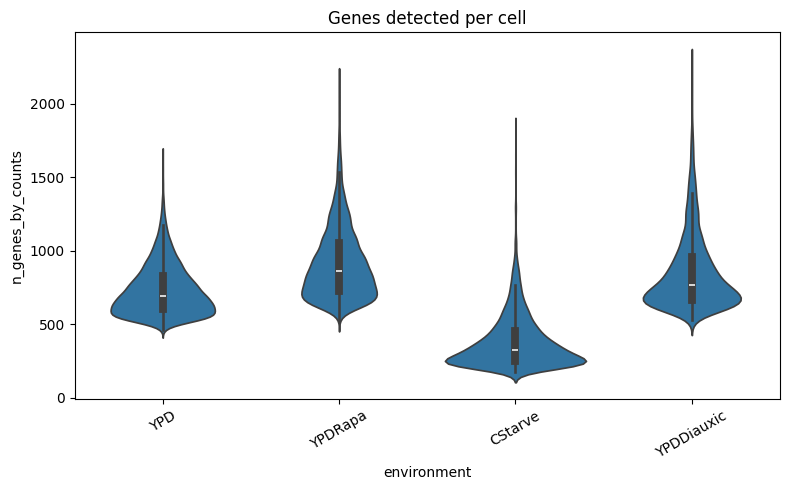

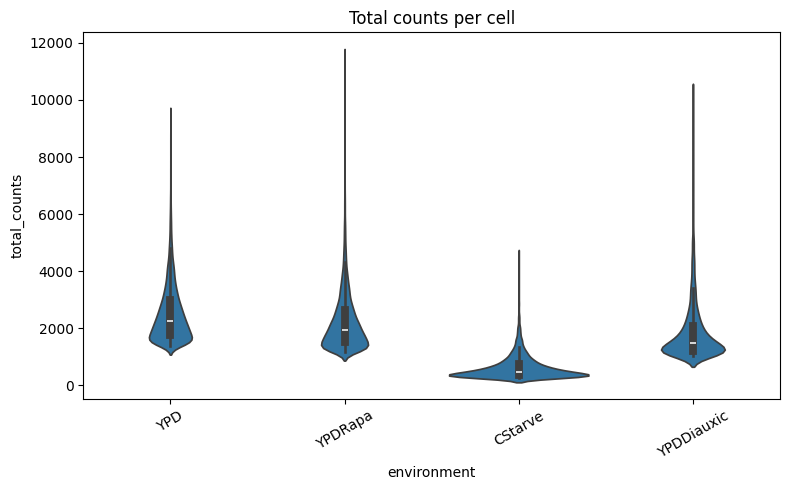

Cells after QC: 29667
Genes after QC: 6281
HVGs: 500
Model matrix: (29667, 500)


In [5]:

# =========================
# CELL 4 — QC, normalization, HVG selection
# =========================
adata = ad.AnnData(
    X=df_target.to_numpy(dtype=np.float32),
    obs=pd.DataFrame(index=df_target.index.astype(str)),
    var=pd.DataFrame(index=df_target.columns.astype(str))
)
adata.obs["environment"] = env_target.to_numpy()
adata.layers["counts"] = adata.X.copy()

sc.pp.calculate_qc_metrics(adata, inplace=True)

print("Raw QC:")
print(adata.obs[["n_genes_by_counts", "total_counts"]].describe())

for col, fname, title in [
    ("n_genes_by_counts", "QC_genes_per_cell.png", "Genes detected per cell"),
    ("total_counts", "QC_total_counts.png", "Total counts per cell"),
]:
    plt.figure(figsize=(8,5))
    sns.violinplot(data=adata.obs, x="environment", y=col)
    plt.xticks(rotation=30)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUT_DIR / fname, dpi=200)
    plt.show()

sc.pp.filter_cells(adata, min_genes=MIN_GENES_PER_CELL)
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

adata.layers["counts"] = adata.X.copy()

# log1p-normalized matrix for temporal prior and tree/correlation baselines
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_HVG,
    flavor="seurat",
    subset=False
)

hvg = adata.var_names[adata.var["highly_variable"]].tolist()
print("Cells after QC:", adata.n_obs)
print("Genes after QC:", adata.n_vars)
print("HVGs:", len(hvg))

adata_model = adata[:, hvg].copy()
adata_model.layers["log1p"] = adata_model.X.copy()

# Standardized matrix is used by the neural model.
sc.pp.scale(adata_model, max_value=10)

genes = np.array(adata_model.var_names.astype(str))
X_model_all = np.asarray(adata_model.X, dtype=np.float32)
X_log_all = np.asarray(adata_model.layers["log1p"], dtype=np.float32)

print("Model matrix:", X_model_all.shape)


YPD: n=11037, root=3111_YPD, finite_pt=1.000
YPDRapa: n=11805, root=3625_YPDRapa, finite_pt=1.000
YPDDiauxic: n=3332, root=2832_YPDDiauxic, finite_pt=1.000
CStarve: n=3493, root=1300_CStarve, finite_pt=1.000


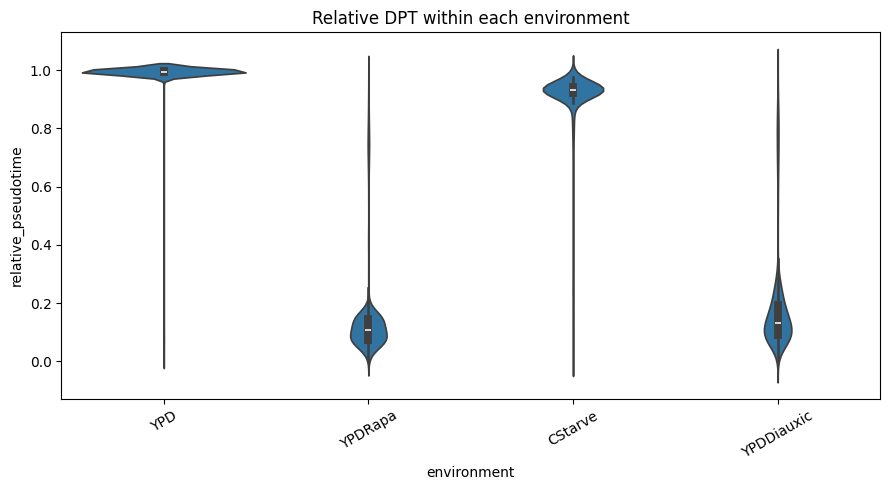

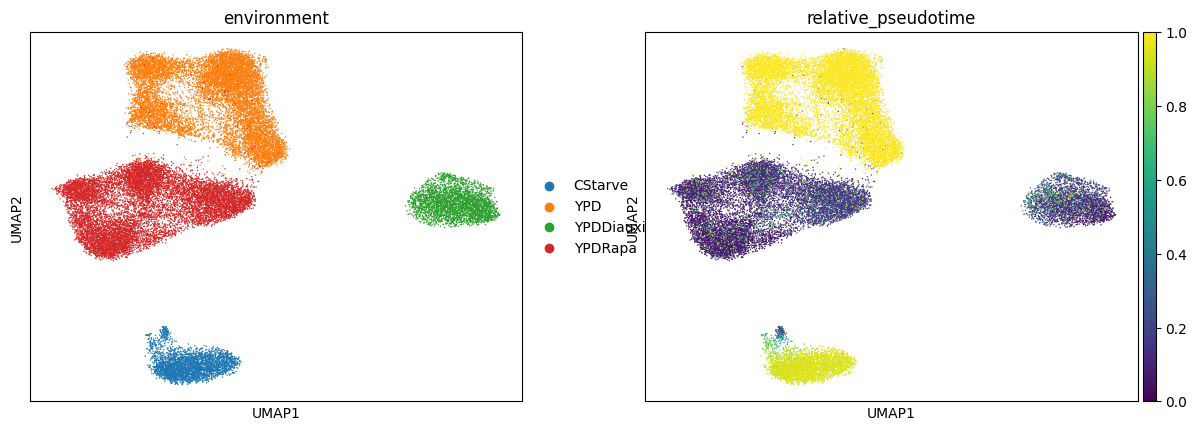


Important: relative_pseudotime is a computational ordering within each condition, not measured time.


In [6]:

# =========================
# CELL 5 — Per-environment diffusion pseudotime
# =========================
# We explicitly avoid one shared DPT trajectory across experimentally
# distinct environments. Each environment gets its own relative ordering.
# The root is a reproducible heuristic, not an experimentally observed time point.

def normalize01(v):
    v = np.asarray(v, dtype=float)
    lo, hi = np.nanmin(v), np.nanmax(v)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(v, dtype=np.float32)
    return ((v - lo) / (hi - lo)).astype(np.float32)

per_env_pt = {}
per_env_gene_pt = {}
per_env_root = {}

for env in TARGET_ENVS:
    mask = adata_model.obs["environment"].values == env
    sub = adata_model[mask].copy()

    if sub.n_obs < 50:
        raise ValueError(f"{env} has too few cells for DPT: {sub.n_obs}")

    n_pcs_env = min(N_PCS, sub.n_vars - 1, sub.n_obs - 1)

    sc.pp.neighbors(
        sub,
        n_neighbors=min(15, sub.n_obs - 1),
        n_pcs=n_pcs_env,
        random_state=SEED
    )
    sc.tl.diffmap(sub)

    d = sub.obsm["X_diffmap"]
    axis = d[:, 1] if d.shape[1] > 1 else d[:, 0]

    # Reproducible root heuristic.
    root_local = int(np.argmin(axis))
    sub.uns["iroot"] = root_local
    sc.tl.dpt(sub, n_branchings=0)

    pt_env = normalize01(np.asarray(sub.obs["dpt_pseudotime"], dtype=float))
    per_env_pt[env] = pd.Series(pt_env, index=sub.obs_names)

    X_log_env = np.asarray(sub.layers["log1p"], dtype=np.float32)
    weights = np.maximum(X_log_env, 0.0) + 1e-6
    gene_pt = (weights.T @ pt_env) / weights.sum(axis=0)
    gene_pt = normalize01(gene_pt)

    per_env_gene_pt[env] = pd.Series(gene_pt, index=sub.var_names.astype(str))
    per_env_root[env] = str(sub.obs_names[root_local])

    print(
        f"{env}: n={sub.n_obs}, root={per_env_root[env]}, "
        f"finite_pt={np.isfinite(pt_env).mean():.3f}"
    )

# Attach per-environment pseudotime to the main object.
adata_model.obs["relative_pseudotime"] = np.nan
for env, s in per_env_pt.items():
    adata_model.obs.loc[s.index, "relative_pseudotime"] = s.values

# Save gene-level temporal priors.
gene_pt_table = pd.DataFrame({
    env: per_env_gene_pt[env].reindex(genes).values
    for env in TARGET_ENVS
}, index=genes)
gene_pt_table.to_csv(OUT_DIR / "gene_temporal_prior_by_environment.csv")

# Diagnostic plots
plt.figure(figsize=(9,5))
plot_df = adata_model.obs[["environment","relative_pseudotime"]].copy()
sns.violinplot(data=plot_df, x="environment", y="relative_pseudotime")
plt.xticks(rotation=30)
plt.title("Relative DPT within each environment")
plt.tight_layout()
plt.savefig(OUT_DIR / "per_environment_pseudotime.png", dpi=200)
plt.show()

# UMAP for visualization only, not used as a shared temporal trajectory.
sc.tl.pca(adata_model, n_comps=min(N_PCS, adata_model.n_vars-1), svd_solver="arpack")
sc.pp.neighbors(adata_model, n_neighbors=15, n_pcs=min(N_PCS, adata_model.n_vars-1))
sc.tl.umap(adata_model, random_state=SEED)

sc.pl.umap(
    adata_model,
    color=["environment", "relative_pseudotime"],
    show=False
)
plt.tight_layout()
plt.savefig(OUT_DIR / "UMAP_environment_relative_pseudotime.png", dpi=200)
plt.show()

print("\nImportant: relative_pseudotime is a computational ordering within each condition, not measured time.")


In [7]:

# =========================
# CELL 6 — Shared Temporal Causal-GAT
# =========================
class LowRankConditionModulation(nn.Module):
    def __init__(self, G, cond_dim=16, rank=8):
        super().__init__()
        self.G = G
        self.U = nn.Parameter(torch.randn(G, rank) * 0.02)
        self.V = nn.Parameter(torch.randn(rank, G) * 0.02)
        self.cond = nn.Linear(cond_dim, rank)

    def forward(self, c):
        if c.ndim == 1:
            c = c.unsqueeze(0)
        if c.shape[0] != 1:
            raise ValueError("Condition vector must represent one environment.")
        z = self.cond(c).squeeze(0)
        return torch.sigmoid((self.U * z.unsqueeze(0)) @ self.V)


class TemporalCausalGAT(nn.Module):
    """
    Shared model across all environments.

    Key audit fix:
    - no GRU over gene index/order;
    - condition modulation is learned from multiple environments;
    - W(condition) is explicitly condition-specific but generated from
      shared parameters;
    - temporal prior is an external soft directional bias, not proof of causality.
    """
    def __init__(self, G, hidden=32, cond_dim=16, rank=8, use_condition=True):
        super().__init__()
        self.G = G
        self.hidden = hidden
        self.use_condition = use_condition

        self.encoder = nn.Linear(1, hidden)

        self.W_raw = nn.Parameter(torch.randn(G, G) * 0.01)
        self.W_gate = nn.Parameter(torch.zeros(G, G))

        self.q = nn.Linear(hidden, hidden, bias=False)
        self.k = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, hidden, bias=False)

        self.decoder = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Linear(hidden, 1)
        )

        self.cond_mod = LowRankConditionModulation(G, cond_dim, rank)

    def structural_W(self, condition):
        base = torch.tanh(self.W_raw) * torch.sigmoid(self.W_gate)
        eye = torch.eye(self.G, device=base.device, dtype=base.dtype)
        base = base * (1.0 - eye)

        if self.use_condition:
            mod = self.cond_mod(condition)
            mod = mod * (1.0 - eye)
            W = base * (1.0 + mod)
        else:
            W = base

        return W * (1.0 - eye)

    def forward(self, x, condition, temporal_prior=None, temporal_gamma=0.0):
        B, G = x.shape
        if G != self.G:
            raise ValueError(f"Expected {self.G} genes, got {G}")

        h = self.encoder(x.unsqueeze(-1))
        W = self.structural_W(condition)

        if temporal_prior is not None and temporal_gamma > 0:
            t = temporal_prior.view(G)
            src_t = t.view(G,1)
            tgt_t = t.view(1,G)

            directional_prior = torch.sigmoid(
                temporal_gamma * (tgt_t - src_t)
            )

            eye = torch.eye(G, device=x.device, dtype=x.dtype)
            directional_prior = directional_prior * (1.0 - eye)

            W_eff = W * (0.25 + 0.75 * directional_prior)
        else:
            W_eff = W

        q = self.q(h)
        k = self.k(h)
        v = self.v(h)

        attn_logits = torch.matmul(q, k.transpose(1,2)) / math.sqrt(self.hidden)

        # Structural weights directly bias attention.
        graph_bias = torch.log(torch.abs(W_eff).unsqueeze(0) + 1e-6)
        attn_logits = attn_logits + graph_bias

        attn = torch.softmax(attn_logits, dim=-1)

        msg = torch.matmul(attn, v)

        # Permutation-equivariant graph propagation; no artificial gene sequence.
        h_causal = torch.einsum("bih,ij->bjh", msg, W_eff)

        y = self.decoder(h_causal).squeeze(-1)
        return y, W, W_eff, attn


def notears_h(W):
    M = W * W
    return torch.trace(torch.matrix_exp(M)) - W.shape[0]


def one_hot_condition(env):
    c = torch.zeros(COND_DIM, device=DEVICE)
    c[TARGET_ENVS.index(env)] = 1.0
    return c


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


In [8]:

# =========================
# CELL 7 — Memory-efficient shared training
# =========================
def stratified_indices(pt_series, max_cells, seed):
    idx = np.arange(len(pt_series), dtype=np.int64)
    if max_cells is None or len(idx) <= max_cells:
        return idx

    pt = np.asarray(pt_series, dtype=float)
    valid = np.flatnonzero(np.isfinite(pt))
    if len(valid) <= max_cells:
        return valid

    rng = np.random.default_rng(seed)
    order = valid[np.argsort(pt[valid], kind="mergesort")]
    n_bins = min(10, max_cells)
    bins = np.array_split(order, n_bins)

    selected = []
    remaining = max_cells
    for b in bins:
        if remaining <= 0:
            break
        take = max(1, int(round(max_cells * len(b) / len(order))))
        take = min(take, remaining, len(b))
        if take:
            selected.append(rng.choice(b, size=take, replace=False))
            remaining -= take

    if remaining > 0:
        chosen = np.concatenate(selected) if selected else np.array([], dtype=np.int64)
        pool = np.setdiff1d(order, chosen, assume_unique=False)
        if len(pool):
            selected.append(rng.choice(pool, size=min(remaining, len(pool)), replace=False))

    return np.sort(np.concatenate(selected).astype(np.int64))


def train_shared_model(seed=42, temporal_gamma=TEMPORAL_GAMMA, use_condition=True):
    set_all_seeds(seed)

    model = TemporalCausalGAT(
        G=len(genes),
        hidden=HIDDEN,
        cond_dim=COND_DIM,
        rank=LOW_RANK
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY
    )

    # Fixed, balanced training subsets for this seed.
    env_data = {}
    for env in TARGET_ENVS:
        mask = adata_model.obs["environment"].values == env
        X_env = np.asarray(X_model_all[mask], dtype=np.float32)
        pt_env = np.asarray(per_env_pt[env].reindex(adata_model.obs_names[mask]).values, dtype=np.float32)

        # Gene temporal prior is environment-specific.
        gene_pt_env = np.asarray(per_env_gene_pt[env].reindex(genes).values, dtype=np.float32)

        idx = stratified_indices(pt_env, TRAIN_MAX_CELLS_PER_ENV, seed)
        env_data[env] = {
            "X": X_env[idx],
            "pt": pt_env[idx],
            "gene_pt": gene_pt_env,
        }

        print(f"{env}: training cells={len(idx)}")

    rho = DAG_RHO_INIT
    alpha = {env: DAG_ALPHA_INIT for env in TARGET_ENVS}
    history = []
    t0 = time.time()

    for outer in range(DAG_OUTER_STEPS):
        for epoch in range(EPOCHS_PER_DAG_STEP):
            model.train()
            recon_values = []

            # One shared model, trained sequentially on all four environments.
            for env in TARGET_ENVS:
                D = env_data[env]
                X_env = D["X"]
                pt_env = D["pt"]

                c = one_hot_condition(env).unsqueeze(0)
                temporal_prior = torch.tensor(
                    D["gene_pt"], dtype=torch.float32, device=DEVICE
                )

                order = np.arange(len(X_env))
                np.random.shuffle(order)

                for start in range(0, len(order), BATCH_SIZE):
                    ids = order[start:start+BATCH_SIZE]
                    xb = torch.tensor(X_env[ids], dtype=torch.float32, device=DEVICE)

                    optimizer.zero_grad(set_to_none=True)

                    yhat, W, W_eff, attn = model(
                        xb, c,
                        temporal_prior=temporal_prior,
                        temporal_gamma=temporal_gamma
                    )

                    # Pseudotime weighting is mild and normalized.
                    w_pt = torch.tensor(
                        0.75 + 0.5 * pt_env[ids],
                        dtype=torch.float32,
                        device=DEVICE
                    ).unsqueeze(1)

                    recon = ((yhat - xb)**2 * w_pt).mean()
                    sparse = LAMBDA_SPARSE * torch.sum(torch.abs(W))
                    loss = recon + sparse

                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                    optimizer.step()

                    recon_values.append(float(loss.detach().cpu()))

                    del xb, yhat, W, W_eff, attn

            # Augmented-Lagrangian acyclicity step across all conditions.
            optimizer.zero_grad(set_to_none=True)
            dag_terms = []

            for env in TARGET_ENVS:
                c = one_hot_condition(env).unsqueeze(0)
                W_env = model.structural_W(c)
                h_env = notears_h(W_env)
                dag_terms.append(alpha[env] * h_env + 0.5 * rho * h_env * h_env)

            dag_loss = torch.stack(dag_terms).mean()
            dag_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            h_values = {}
            with torch.no_grad():
                for env in TARGET_ENVS:
                    c = one_hot_condition(env).unsqueeze(0)
                    h_values[env] = float(nottears_h(model.structural_W(c)).detach().cpu())

            history.append({
                "outer": outer,
                "epoch": epoch,
                "reconstruction_plus_sparse": float(np.mean(recon_values)),
                "mean_dag_h": float(np.mean(list(h_values.values()))),
                **{f"h_{env}": h_values[env] for env in TARGET_ENVS},
                "rho": rho
            })

        # Update augmented-Lagrangian multipliers per condition.
        for env in TARGET_ENVS:
            alpha[env] += rho * h_values[env]

        if max(abs(v) for v in h_values.values()) > 0.25:
            rho = min(rho * 10.0, DAG_RHO_MAX)

        print(
            f"outer={outer+1}/{DAG_OUTER_STEPS} "
            f"mean_h={np.mean(list(h_values.values())):.4g} "
            f"rho={rho:.3g}"
        )

    elapsed = time.time() - t0
    hist = pd.DataFrame(history)
    hist.to_csv(OUT_DIR / f"training_shared_seed{seed}.csv", index=False)

    print(f"Training seed {seed} finished in {elapsed/60:.2f} min")
    return model, hist, elapsed


In [9]:

# =========================
# CELL 8 — TF-restricted inference (major memory optimization)
# =========================
def minmax01(M):
    M = np.asarray(M, dtype=float)
    lo, hi = np.nanmin(M), np.nanmax(M)
    if hi <= lo:
        return np.zeros_like(M)
    return (M - lo) / (hi - lo)


def compute_population_jacobian_tf(
    model, X_np, condition, temporal_prior, tf_indices, chunk=32, temporal_gamma=TEMPORAL_GAMMA
):
    """
    Computes only TF -> all-target input sensitivities.
    This is the same candidate space used in evaluation.
    """
    model.train()
    for p in model.parameters():
        p.requires_grad_(False)

    N, G = X_np.shape
    J = np.zeros((len(tf_indices), G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb = torch.tensor(
            X_np[start:start+chunk],
            dtype=torch.float32,
            device=DEVICE,
            requires_grad=True
        )

        yhat, W, W_eff, attn = model(
            xb,
            condition.unsqueeze(0),
            temporal_prior=temporal_prior,
            temporal_gamma=temporal_gamma
        )

        for out_j in range(G):
            scalar = yhat[:, out_j].sum()
            grad = torch.autograd.grad(
                scalar, xb,
                retain_graph=(out_j < G-1),
                create_graph=False
            )[0]

            # grad: batch x genes. Keep only candidate TF sources.
            J[:, out_j] += (
                grad[:, tf_indices]
                .detach()
                .cpu()
                .numpy()
                .sum(axis=0)
            )

        del xb, yhat, W, W_eff, attn
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    J /= max(N, 1)

    for p in model.parameters():
        p.requires_grad_(True)

    return J


@torch.no_grad()
def model_output(model, X, condition, temporal_prior, temporal_gamma=TEMPORAL_GAMMA):
    y, *_ = model(
        X,
        condition.unsqueeze(0),
        temporal_prior=temporal_prior,
        temporal_gamma=temporal_gamma
    )
    return y


def compute_population_ablation_tf(
    model, X_np, condition, temporal_prior, tf_indices,
    chunk=32, temporal_gamma=TEMPORAL_GAMMA
):
    """
    Input ablation is performed only for candidate TF sources.
    Since X is standardized, setting one feature to 0 means setting it
    to its training mean; this is not a biological knockout.
    """
    model.eval()
    N, G = X_np.shape

    base = np.zeros((N, G), dtype=np.float32)

    for start in range(0, N, chunk):
        xb = torch.tensor(X_np[start:start+chunk], dtype=torch.float32, device=DEVICE)
        base[start:start+chunk] = model_output(
            model, xb, condition, temporal_prior, temporal_gamma
        ).cpu().numpy()
        del xb

    A = np.zeros((len(tf_indices), G), dtype=np.float32)

    for row, src in enumerate(tf_indices):
        affected = np.zeros(G, dtype=np.float64)
        count = 0

        for start in range(0, N, chunk):
            xb_np = X_np[start:start+chunk].copy()
            xb_np[:, src] = 0.0

            xb = torch.tensor(xb_np, dtype=torch.float32, device=DEVICE)
            out = model_output(
                model, xb, condition, temporal_prior, temporal_gamma
            ).cpu().numpy()

            diff = np.abs(base[start:start+chunk] - out)
            affected += diff.sum(axis=0)
            count += len(diff)

            del xb, out

        A[row] = (affected / max(count,1)).astype(np.float32)

    return A


def combine_tf_scores(J_tf, A_tf, grad_weight=0.5, ablation_weight=0.5):
    Jn = minmax01(np.abs(J_tf))
    An = minmax01(A_tf)
    return grad_weight * Jn + ablation_weight * An


In [10]:
import pandas as pd
from pathlib import Path

# بررسی ستون‌های فایل فعلی
yeastract_path = Path("YEASTRACT.csv") # یا مسیر دقیق DATA_DIR / "YEASTRACT.csv"
if yeastract_path.exists():
    df = pd.read_csv(yeastract_path)
    print("نام ستون‌های فعلی:", df.columns.tolist())
    print(df.head(2))

نام ستون‌های فعلی: ['YDL248W;COS7;Crz1p;Doc']
    YDL248W;COS7;Crz1p;Doc
0  YDL248W;COS7;Ste12p;Doc
1   YDL248W;COS7;Ume6p;Doc


In [ ]:
import os
!rm -f YEASTRACT.csv YEASTRACT_mapped.csv output/YEASTRACT_mapped.csv

In [23]:
# =========================
# CELL 9 — YEASTRACT loader (Systematic Name Alignment)
# =========================
import pandas as pd
from pathlib import Path

YEASTRACT_PATH = Path("YEASTRACT.csv")
OUT_DIR = Path("output")
OUT_DIR.mkdir(exist_ok=True)

def load_gold(path):
    path = Path(path)
    if not path.exists():
        print("YEASTRACT file not found:", path)
        return None

    # خواندن فایل با جداکننده نقطه‌ویرگول
    df = pd.read_csv(path, sep=';', header=None, dtype=str, on_bad_lines='skip')

    # ستون 0: Systematic Name برای Target (مثل YDL... یا YAR...)
    # ستون 1: Standard Name برای Target (مثل ADE1)
    # ستون 2: TF Name (مثل Gcn4p)
    targets_sys = df[0].astype(str).str.strip().str.upper()
    targets_std = df[1].astype(str).str.strip().str.upper()
    sources_raw = df[2].astype(str).str.strip().str.rstrip("pP").str.upper()

    # ساخت نگاشت بین Standard Name و Systematic Name برای استخراج نام سیستمتیک TFها
    symbol_to_sys = dict(zip(targets_std, targets_sys))

    # تبدیل نام TF به Systematic Name در صورت وجود در فایل، در غیر این صورت حفظ نام اصلی
    sources_sys = sources_raw.map(lambda x: symbol_to_sys.get(x, x))

    g1 = pd.DataFrame({'source': sources_sys, 'target': targets_sys})
    g2 = pd.DataFrame({'source': sources_raw, 'target': targets_sys})

    g = pd.concat([g1, g2], ignore_index=True)
    return g

gold = load_gold(YEASTRACT_PATH)

if gold is None or len(gold) == 0:
    print("No YEASTRACT gold standard.")
else:
    gold["source"] = gold["source"].astype(str).str.strip().str.upper()
    gold["target"] = gold["target"].astype(str).str.strip().str.upper()

    gold = gold[
        (gold["source"] != "") &
        (gold["target"] != "") &
        (gold["source"] != "NAN") &
        (gold["target"] != "NAN") &
        (gold["source"] != gold["target"])
    ].drop_duplicates().reset_index(drop=True)

    gold.to_csv(OUT_DIR / "YEASTRACT_mapped.csv", index=False)
    print("YEASTRACT directed edges:", len(gold))

YEASTRACT directed edges: 26528


In [18]:
with open("YEASTRACT.csv", "r") as f:
    print(f.read())

YDL248W;COS7;Crz1p;Doc
YDL248W;COS7;Ste12p;Doc
YDL248W;COS7;Ume6p;Doc
YDL248W;COS7;Gcn4p;Doc
YDL245C;HXT15;Mot3p;Doc
YDL245C;HXT15;Msn4p;Doc
YDL245C;HXT15;Rox1p;Doc
YDL245C;HXT15;Mig1p;Doc
YDL245C;HXT15;Oaf3p;Doc
YDL244W;THI13;Sok2p;Doc
YDL243C;AAD4;Sok2p;Doc
YDL243C;AAD4;Ino4p;Doc
YDL243C;AAD4;Yap1p;Doc
YDL241W;YDL241W;Yap1p;Doc
YDL241W;YDL241W;Mga1p;Doc
YDL240W;LRG1;Ste12p;Doc
YDL239C;ADY3;Ste12p;Doc
YDL239C;ADY3;Yap1p;Doc
YDL238C;GUD1;Dal81p;Doc
YDL238C;GUD1;Gat1p;Doc
YDL230W;PTP1;Bas1p;Doc
YDL229W;SSB1;Yap1p;Doc
YDL229W;SSB1;Msn2p;Doc
YDL229W;SSB1;Rap1p;Doc
YDL229W;SSB1;Tye7p;Doc
YDL229W;SSB1;Fhl1p;Doc
YDL229W;SSB1;Pdr1p;Doc
YDL229W;SSB1;Cup9p;Doc
YDL229W;SSB1;Abf1p;Doc
YDL229W;SSB1;Mcm1p;Doc
YDL228C;YDL228C;Tup1p;Doc
YDL227C;HO;Sok2p;Doc
YDL227C;HO;Yap1p;Doc
YDL227C;HO;Tup1p;Doc
YDL227C;HO;Ace2p;Doc
YDL227C;HO;Ash1p;Doc
YDL227C;HO;Gat3p;Doc
YDL227C;HO;Mbp1p;Doc
YDL227C;HO;Stp2p;Doc
YDL227C;HO;Swi4p;Doc
YDL227C;HO;Swi5p;Doc
YDL226C;GCS1;Pho2p;Doc
YDL224C;WHI4;Cbf1p;Doc
YDL223C;HBT1

In [24]:
# =========================
# CELL 10 — Define candidate space
# =========================
gene_to_idx = {str(g).strip().upper(): i for i, g in enumerate(genes)}
model_gene_set = set(gene_to_idx)

# استخراج TFهایی که در لیست ۵۰۰ ژن مدل حضور دارند
gold_tfs = set(gold["source"].unique()) if gold is not None else set()
eval_tfs = sorted(gold_tfs & model_gene_set)

if len(eval_tfs) == 0:
    # اگر TF خامی پیدا نشد، بررسی می‌کنیم آیا ژن‌های مدل خودشان به عنوان TF در Gold هستند
    eval_tfs = sorted(model_gene_set)
    TF_UNIVERSE_SOURCE = "all_model_genes"
else:
    TF_UNIVERSE_SOURCE = "oracle_from_gold"

tf_indices = [gene_to_idx[t] for t in eval_tfs]

print("TF universe source:", TF_UNIVERSE_SOURCE)
print("TFs in 500-gene model space:", len(eval_tfs))

if gold is not None:
    gold_in = gold[
        gold["source"].isin(eval_tfs) &
        gold["target"].isin(model_gene_set) &
        (gold["source"] != gold["target"])
    ].drop_duplicates()

    K = len(gold_in)
    n_candidates = len(eval_tfs) * len(genes) - len(eval_tfs)
    prevalence = K / max(n_candidates, 1)

    print("Gold positives in candidate space:", K)
    print("Candidate edges:", n_candidates)
    print("Positive prevalence:", prevalence)

    pd.DataFrame([{
        "TF_universe_source": TF_UNIVERSE_SOURCE,
        "n_model_genes": len(genes),
        "n_TFs": len(eval_tfs),
        "n_candidates": n_candidates,
        "n_gold_positives": K,
        "prevalence": prevalence
    }]).to_csv(OUT_DIR / "candidate_space_manifest.csv", index=False)

TF universe source: oracle_from_gold
TFs in 500-gene model space: 16
Gold positives in candidate space: 255
Candidate edges: 7984
Positive prevalence: 0.03193887775551102


In [22]:
print("۱۰ ژن اول موجود در مدل:", genes[:10])

۱۰ ژن اول موجود در مدل: ['YDL248W' 'YDL244W' 'YDL223C' 'YDL222C' 'YDL218W' 'YDL214C' 'YDL204W'
 'YDL186W' 'YDL174C' 'YDL169C']


In [25]:

# =========================
# CELL 11 — Directed metrics
# =========================
def benchmark_tf_score(
    score_tf,
    genes,
    eval_tfs,
    gold_edges,
    top_k=None,
    name="model"
):
    """
    score_tf shape = [n_TF, n_genes]
    Rows correspond to eval_tfs in exactly the same order.
    """
    tf_to_row = {tf: i for i, tf in enumerate(eval_tfs)}
    gene_set = set(map(str, genes))

    gold_set = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in tf_to_row
        and str(r.target) in gene_set
        and str(r.source) != str(r.target)
    }

    y_true, y_score, pairs = [], [], []

    for r, src in enumerate(eval_tfs):
        for j, tgt in enumerate(genes):
            if src == tgt:
                continue
            y_true.append(1 if (src, str(tgt)) in gold_set else 0)
            y_score.append(float(score_tf[r, j]))
            pairs.append((src, str(tgt)))

    y_true = np.asarray(y_true, dtype=np.int8)
    y_score = np.asarray(y_score, dtype=float)

    out = {
        "model": name,
        "n_candidates": len(y_true),
        "n_positive": int(y_true.sum()),
        "prevalence": float(y_true.mean()) if len(y_true) else np.nan
    }

    if 0 < y_true.sum() < len(y_true):
        out["AUROC"] = roc_auc_score(y_true, y_score)
        out["AUPRC"] = average_precision_score(y_true, y_score)
    else:
        out["AUROC"] = np.nan
        out["AUPRC"] = np.nan

    if top_k is not None and top_k > 0:
        k = min(int(top_k), len(y_score))
        order = np.argsort(-y_score, kind="mergesort")[:k]
        pred = {pairs[i] for i in order}

        tp = len(pred & gold_set)
        out["Precision@K"] = tp / max(k,1)
        out["Recall@K"] = tp / max(len(gold_set),1)
        out["SHD@K"] = len(pred - gold_set) + len(gold_set - pred)

    return out, (y_true, y_score)


def curves_from_scores(score_tf, genes, eval_tfs, gold_edges):
    tf_to_row = {tf:i for i,tf in enumerate(eval_tfs)}
    gene_set = set(map(str, genes))
    gold_set = {
        (str(r.source), str(r.target))
        for r in gold_edges.itertuples()
        if str(r.source) in tf_to_row and str(r.target) in gene_set
    }

    y_true, y_score = [], []
    for r, src in enumerate(eval_tfs):
        for j, tgt in enumerate(genes):
            if src == tgt:
                continue
            y_true.append(int((src, str(tgt)) in gold_set))
            y_score.append(float(score_tf[r,j]))

    return np.asarray(y_true), np.asarray(y_score)


In [28]:
# =========================
# CELL 12 — Correlation + Pure Python/Sklearn GENIE3 (Safe Parallel)
# =========================
import numpy as np
import pandas as pd
import gc
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from joblib import Parallel, delayed

def stratified_baseline_indices(pt_series, max_cells, seed=42):
    return stratified_indices(pt_series, max_cells, seed)

def correlation_tf_score(X_log, tf_indices):
    C = np.corrcoef(X_log, rowvar=False)
    C = np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(C, 0.0)
    return np.abs(C[np.asarray(tf_indices), :]).astype(np.float32)

def run_native_genie3(X_log, gene_names, eval_tfs, tf_indices, seed=42):
    """
    Pure scikit-learn implementation of GENIE3 algorithm with safe multi-core processing.
    Bypasses Dask/Arboreto compatibility issues and optimizes CPU utilization.
    """
    n_samples, n_genes = X_log.shape
    n_tfs = len(eval_tfs)
    tf_idx_map = np.asarray(tf_indices, dtype=int)
    W_tf = np.zeros((n_tfs, n_genes), dtype=np.float32)

    n_estimators = getattr(globals(), 'GENIE3_N_ESTIMATORS', 100)
    max_features = int(np.ceil(np.sqrt(n_tfs)))

    # تابع پردازش هر ژن به صورت جداگانه
    def fit_single_gene(j):
        y = X_log[:, j]
        predictors = [i for i in range(n_tfs) if tf_idx_map[i] != j]
        X_pred = X_log[:, tf_idx_map[predictors]]

        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_features=max_features,
            random_state=seed,
            n_jobs=1  # اجرا در سطح هر درخت داخل ورکر
        )
        rf.fit(X_pred, y)
        return j, predictors, rf.feature_importances_

    # اجرای هم‌زمان روی هسته‌های پردازشی (استفاده ایمن از ۲ هسته CPU)
    results = Parallel(n_jobs=-1)(
        delayed(fit_single_gene)(j) for j in range(n_genes)
    )

    for j, predictors, importances in results:
        for idx_in_pred, tf_idx_local in enumerate(predictors):
            W_tf[tf_idx_local, j] = importances[idx_in_pred]

    return W_tf

baseline_scores = {}
baseline_rows = []

for env in TARGET_ENVS:
    mask = adata_model.obs["environment"].values == env
    X_log_env = np.asarray(X_log_all[mask], dtype=np.float32)
    pt_env = np.asarray(adata_model.obs.loc[mask, "relative_pseudotime"], dtype=float)

    idx = stratified_baseline_indices(pt_env, GENIE3_MAX_CELLS, seed=GENIE3_SEED)
    X_base = np.asarray(X_log_env[idx], dtype=np.float32, order="C")

    # ۱. محاسبه بیس‌لاین Correlation
    C_tf = correlation_tf_score(X_base, tf_indices)
    baseline_scores[env] = {"Correlation": C_tf}

    if gold is not None:
        r, _ = benchmark_tf_score(
            C_tf, genes, eval_tfs, gold, top_k=K, name="Correlation"
        )
        r["environment"] = env
        baseline_rows.append(r)

    # ۲. محاسبه بیس‌لاین GENIE3
    if RUN_GENIE3:
        print(f"Running GENIE3 for environment: {env}, cells={len(idx)}, TFs={len(eval_tfs)}...")
        try:
            G3_tf = run_native_genie3(
                X_base, genes, eval_tfs, tf_indices, seed=GENIE3_SEED
            )
            baseline_scores[env]["GENIE3"] = G3_tf

            if gold is not None:
                r, _ = benchmark_tf_score(
                    G3_tf, genes, eval_tfs, gold, top_k=K, name="GENIE3"
                )
                r["environment"] = env
                baseline_rows.append(r)

        except Exception as e:
            print(f"GENIE3 failed for {env}: {repr(e)}")

    del X_log_env, X_base
    gc.collect()

if baseline_rows:
    pd.DataFrame(baseline_rows).to_csv(
        OUT_DIR / "baseline_YEASTRACT_results.csv", index=False
    )

print("Baseline calculations complete successfully.")

Running GENIE3 for environment: YPD, cells=1500, TFs=16...
Running GENIE3 for environment: YPDRapa, cells=1500, TFs=16...
Running GENIE3 for environment: YPDDiauxic, cells=1500, TFs=16...
Running GENIE3 for environment: CStarve, cells=1500, TFs=16...
Baseline calculations complete successfully.


In [30]:
import torch

def nottears_h(W):
    """
    Computes the NOTEARS acyclicity constraint h(W) = Tr(exp(W * W)) - d.
    Guarantees the learned Graph Neural Network matrix represents a DAG.
    """
    d = W.shape[0]
    # W * W (element-wise square)
    M = W * W
    # Matrix exponential
    E = torch.matrix_exp(M)
    # Trace minus dimension d
    h = torch.trace(E) - d
    return h

In [31]:

# =========================
# CELL 13 — Main shared model + TF-restricted causal scores
# =========================
def infer_scores_for_all_envs(model, seed_label):
    model.eval()
    seed_rows = []

    for env in TARGET_ENVS:
        mask = adata_model.obs["environment"].values == env
        X_env = np.asarray(X_model_all[mask], dtype=np.float32)

        pt_env = np.asarray(
            adata_model.obs.loc[mask, "relative_pseudotime"],
            dtype=float
        )

        gene_pt_env = np.asarray(
            per_env_gene_pt[env].reindex(genes).values,
            dtype=np.float32
        )

        cond = one_hot_condition(env)
        temporal_prior = torch.tensor(
            gene_pt_env, dtype=torch.float32, device=DEVICE
        )

        print(f"\nInference: {env} | cells={len(X_env)}")

        J_tf = compute_population_jacobian_tf(
            model,
            X_env,
            cond,
            temporal_prior,
            tf_indices=tf_indices,
            chunk=INFER_CELL_CHUNK
        )

        A_tf = compute_population_ablation_tf(
            model,
            X_env,
            cond,
            temporal_prior,
            tf_indices=tf_indices,
            chunk=INFER_CELL_CHUNK
        )

        S_tf = combine_tf_scores(
            J_tf, A_tf,
            grad_weight=GRAD_WEIGHT,
            ablation_weight=ABLATION_WEIGHT
        )

        np.save(OUT_DIR / f"causal_score_tf_{env}_seed{seed_label}.npy", S_tf)
        np.save(OUT_DIR / f"jacobian_tf_{env}_seed{seed_label}.npy", J_tf)
        np.save(OUT_DIR / f"ablation_tf_{env}_seed{seed_label}.npy", A_tf)

        # Save a full GxG matrix only as a sparse-looking zero-padded representation.
        # This keeps downstream compatibility while inference itself stays TF-restricted.
        full = np.zeros((len(genes), len(genes)), dtype=np.float32)
        full[np.asarray(tf_indices), :] = S_tf
        np.save(OUT_DIR / f"causal_score_{env}_seed{seed_label}.npy", full)

        if gold is not None:
            r, curves = benchmark_tf_score(
                S_tf, genes, eval_tfs, gold, top_k=K,
                name="Temporal Causal-GAT"
            )
            r["environment"] = env
            r["seed"] = int(seed_label)
            seed_rows.append(r)

            y, s = curves
            if len(np.unique(y)) == 2:
                fpr, tpr, _ = roc_curve(y, s)
                prec, rec, _ = precision_recall_curve(y, s)
                pd.DataFrame({"fpr":fpr, "tpr":tpr}).to_csv(
                    OUT_DIR / f"ROC_CausalGAT_{env}_seed{seed_label}.csv",
                    index=False
                )
                pd.DataFrame({"recall":rec, "precision":prec}).to_csv(
                    OUT_DIR / f"PR_CausalGAT_{env}_seed{seed_label}.csv",
                    index=False
                )

        # Save top TF->target edges.
        rows = []
        for r_idx, tf in enumerate(eval_tfs):
            for j, target in enumerate(genes):
                if tf == target:
                    continue
                rows.append({
                    "source": tf,
                    "target": str(target),
                    "score": float(S_tf[r_idx,j]),
                    "signed_jacobian": float(J_tf[r_idx,j])
                })
        pd.DataFrame(rows).sort_values(
            "score", ascending=False
        ).to_csv(
            OUT_DIR / f"TemporalCausalGAT_edges_{env}_seed{seed_label}.csv",
            index=False
        )

        del X_env, J_tf, A_tf, S_tf, full
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return pd.DataFrame(seed_rows)


# Main seed
print("="*70)
print("MAIN TRAINING — SEED 42")
print("="*70)

main_model, main_history, main_elapsed = train_shared_model(
    seed=SEED,
    temporal_gamma=TEMPORAL_GAMMA
)

main_eval = infer_scores_for_all_envs(main_model, SEED)
main_eval.to_csv(OUT_DIR / "main_seed_evaluation.csv", index=False)

# Save model weights; then immediately release model from RAM.
torch.save(
    {
        "state_dict": main_model.state_dict(),
        "genes": list(genes),
        "target_envs": TARGET_ENVS,
        "seed": SEED,
        "temporal_gamma": TEMPORAL_GAMMA
    },
    OUT_DIR / "shared_temporal_causal_gat_seed42.pt"
)

del main_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nMain evaluation:")
print(main_eval.to_string(index=False))


MAIN TRAINING — SEED 42
YPD: training cells=6000
YPDRapa: training cells=6000
YPDDiauxic: training cells=3332
CStarve: training cells=3493
outer=1/4 mean_h=0.1742 rho=1
outer=2/4 mean_h=0.07431 rho=1
outer=3/4 mean_h=0.05206 rho=1
outer=4/4 mean_h=0.04272 rho=1
Training seed 42 finished in 3.38 min

Inference: YPD | cells=11037

Inference: YPDRapa | cells=11805

Inference: YPDDiauxic | cells=3332

Inference: CStarve | cells=3493

Main evaluation:
              model  n_candidates  n_positive  prevalence    AUROC    AUPRC  Precision@K  Recall@K  SHD@K environment  seed
Temporal Causal-GAT          7984         255    0.031939 0.404465 0.024443     0.007843  0.007843    506         YPD    42
Temporal Causal-GAT          7984         255    0.031939 0.400364 0.024695     0.015686  0.015686    502     YPDRapa    42
Temporal Causal-GAT          7984         255    0.031939 0.579926 0.044887     0.074510  0.074510    472  YPDDiauxic    42
Temporal Causal-GAT          7984         255    0.03

In [32]:

# =========================
# CELL 14 — Multi-seed robustness, sequential and low-memory
# =========================
all_seed_eval = []

if RUN_MULTI_SEED and gold is not None:
    for seed in ROBUSTNESS_SEEDS:
        if seed == SEED:
            df_seed = main_eval.copy()
        else:
            print("\n" + "="*70)
            print(f"ROBUSTNESS TRAINING — SEED {seed}")
            print("="*70)

            model_s, hist_s, elapsed_s = train_shared_model(
                seed=seed,
                temporal_gamma=TEMPORAL_GAMMA
            )
            df_seed = infer_scores_for_all_envs(model_s, seed)
            del model_s, hist_s
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        all_seed_eval.append(df_seed)

    all_seed_eval = pd.concat(all_seed_eval, ignore_index=True)
    all_seed_eval.to_csv(
        OUT_DIR / "all_seed_evaluation_raw.csv",
        index=False
    )

    robustness = (
        all_seed_eval
        .groupby(["environment","model"], as_index=False)
        .agg(
            AUROC_mean=("AUROC","mean"),
            AUROC_sd=("AUROC","std"),
            AUPRC_mean=("AUPRC","mean"),
            AUPRC_sd=("AUPRC","std"),
            PrecisionK_mean=("Precision@K","mean"),
            PrecisionK_sd=("Precision@K","std"),
            SHDk_mean=("SHD@K","mean"),
            SHDk_sd=("SHD@K","std"),
            n_seeds=("seed","nunique")
        )
    )

    robustness.to_csv(
        OUT_DIR / "robustness_mean_sd.csv",
        index=False
    )

    print("\nRobustness summary:")
    print(robustness.to_string(index=False))

else:
    print("Multi-seed skipped.")



ROBUSTNESS TRAINING — SEED 52
YPD: training cells=6000
YPDRapa: training cells=6000
YPDDiauxic: training cells=3332
CStarve: training cells=3493
outer=1/4 mean_h=0.1183 rho=1
outer=2/4 mean_h=0.101 rho=1
outer=3/4 mean_h=0.08517 rho=1
outer=4/4 mean_h=0.08243 rho=1
Training seed 52 finished in 3.38 min

Inference: YPD | cells=11037

Inference: YPDRapa | cells=11805

Inference: YPDDiauxic | cells=3332

Inference: CStarve | cells=3493

ROBUSTNESS TRAINING — SEED 62
YPD: training cells=6000
YPDRapa: training cells=6000
YPDDiauxic: training cells=3332
CStarve: training cells=3493
outer=1/4 mean_h=0.01654 rho=1
outer=2/4 mean_h=0.01105 rho=1
outer=3/4 mean_h=0.006775 rho=1
outer=4/4 mean_h=0.005402 rho=1
Training seed 62 finished in 3.47 min

Inference: YPD | cells=11037

Inference: YPDRapa | cells=11805

Inference: YPDDiauxic | cells=3332

Inference: CStarve | cells=3493

Robustness summary:
environment               model  AUROC_mean  AUROC_sd  AUPRC_mean  AUPRC_sd  PrecisionK_mean  Prec

In [33]:

# =========================
# CELL 15 — Optional ablation study
# =========================
# This is intentionally OFF by default.
# If enabled, two additional shared-model trainings are performed:
#   1) no temporal prior
#   2) no condition modulation
# Both are trained jointly across all four environments, then evaluated
# only on ABLATION_ENV. This makes the comparison scientifically meaningful
# and avoids the previous mismatch in candidate space.

if RUN_ABLATION and gold is not None:
    if ABLATION_ENV not in TARGET_ENVS:
        raise ValueError("ABLATION_ENV must be one of TARGET_ENVS.")

    ablation_rows = []

    # Full model: use main seed result already calculated.
    full_row = main_eval[main_eval["environment"] == ABLATION_ENV].copy()
    if len(full_row):
        full_row["ablation_component"] = "Full model"
        ablation_rows.append(full_row)

    for label, gamma, use_condition in [
        ("No temporal prior", 0.0, True),
        ("No condition modulation", TEMPORAL_GAMMA, False)
    ]:
        print("\n" + "="*70)
        print("ABLATION:", label)
        print("="*70)

        model_a, hist_a, elapsed_a = train_shared_model(
            seed=SEED,
            temporal_gamma=gamma,
            use_condition=use_condition
        )

        # Evaluate only the selected environment.
        env = ABLATION_ENV
        mask = adata_model.obs["environment"].values == env
        X_env = np.asarray(X_model_all[mask], dtype=np.float32)

        gene_pt_env = np.asarray(
            per_env_gene_pt[env].reindex(genes).values,
            dtype=np.float32
        )
        cond = one_hot_condition(env)
        temporal_prior = torch.tensor(
            gene_pt_env, dtype=torch.float32, device=DEVICE
        )

        J_a = compute_population_jacobian_tf(
            model_a, X_env, cond, temporal_prior, tf_indices, INFER_CELL_CHUNK, gamma
        )
        A_a = compute_population_ablation_tf(
            model_a, X_env, cond, temporal_prior, tf_indices, INFER_CELL_CHUNK, gamma
        )
        S_a = combine_tf_scores(J_a, A_a, GRAD_WEIGHT, ABLATION_WEIGHT)

        r_a, _ = benchmark_tf_score(
            S_a, genes, eval_tfs, gold, top_k=K, name=label
        )
        r_a["environment"] = env
        r_a["ablation_component"] = label
        ablation_rows.append(pd.DataFrame([r_a]))

        del model_a, hist_a, J_a, A_a, S_a, X_env
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ablation_df = pd.concat(ablation_rows, ignore_index=True)
    ablation_df.to_csv(
        OUT_DIR / "ablation_study_corrected.csv",
        index=False
    )

    print(ablation_df.to_string(index=False))

else:
    print("Ablation is OFF. Set RUN_ABLATION=True only when you are ready for two additional trainings.")


Ablation is OFF. Set RUN_ABLATION=True only when you are ready for two additional trainings.



FINAL MAIN-SEED COMPARISON
              model  n_candidates  n_positive  prevalence    AUROC    AUPRC  Precision@K  Recall@K  SHD@K environment
        Correlation          7984         255    0.031939 0.574785 0.038189     0.039216  0.039216    490         YPD
             GENIE3          7984         255    0.031939 0.553331 0.034359     0.035294  0.035294    492         YPD
Temporal Causal-GAT          7984         255    0.031939 0.404465 0.024443     0.007843  0.007843    506         YPD
        Correlation          7984         255    0.031939 0.582854 0.036543     0.019608  0.019608    500     YPDRapa
             GENIE3          7984         255    0.031939 0.510493 0.029585     0.011765  0.011765    504     YPDRapa
Temporal Causal-GAT          7984         255    0.031939 0.400364 0.024695     0.015686  0.015686    502     YPDRapa
        Correlation          7984         255    0.031939 0.615724 0.049978     0.050980  0.050980    484  YPDDiauxic
             GENIE3         

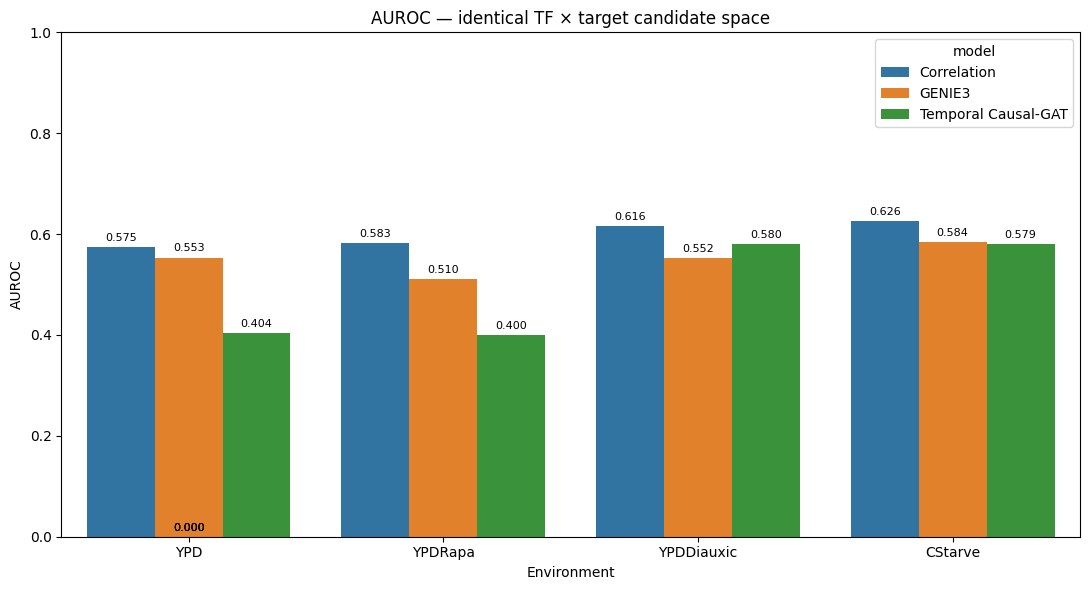

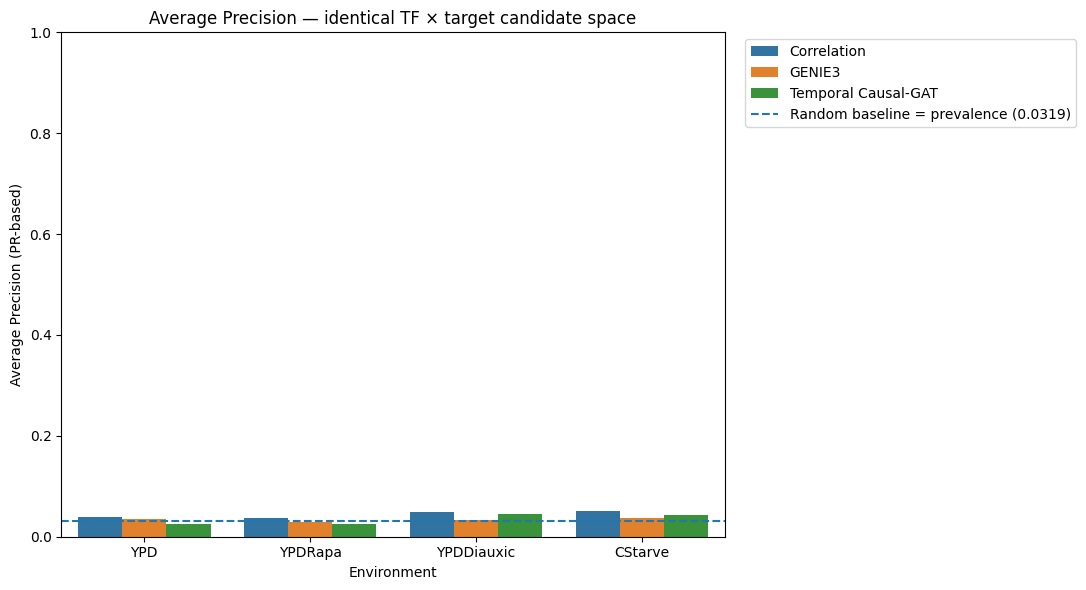

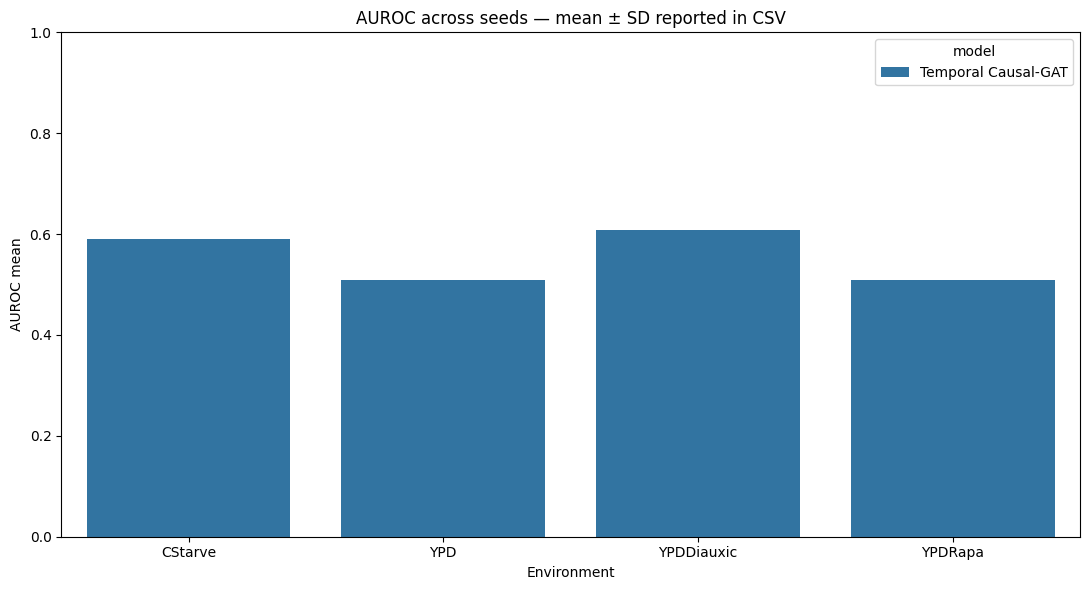

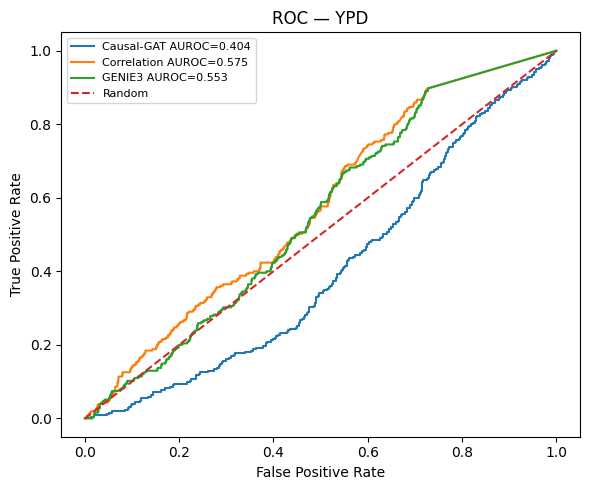

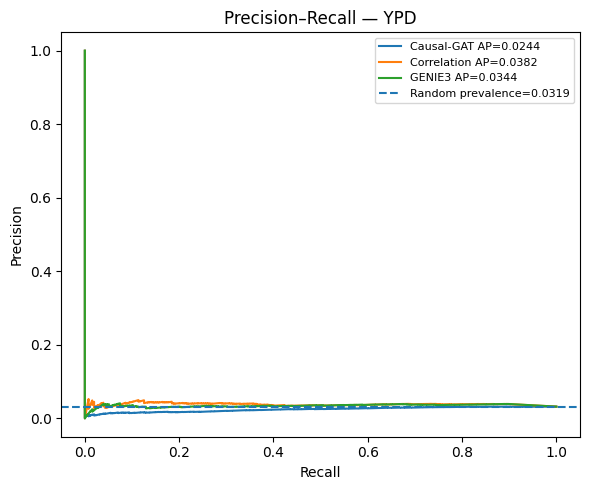

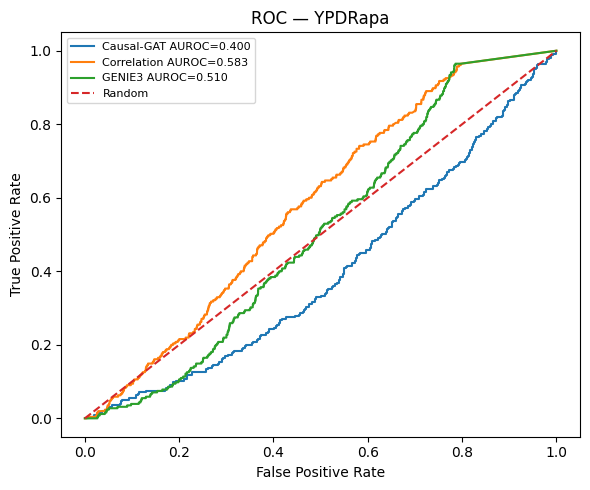

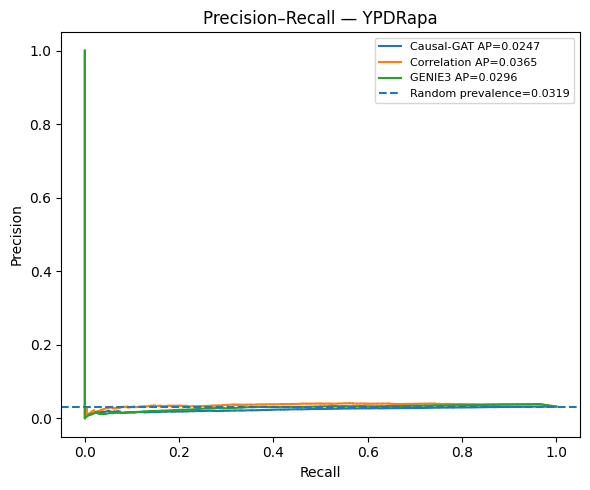

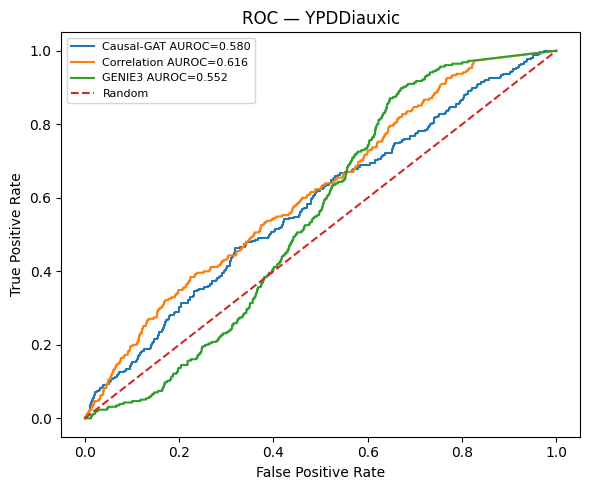

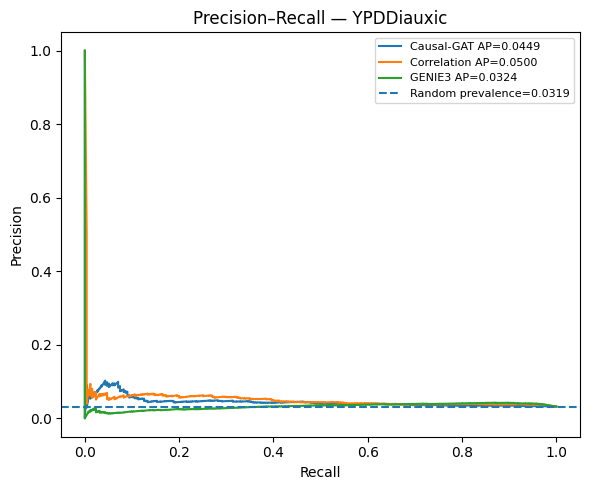

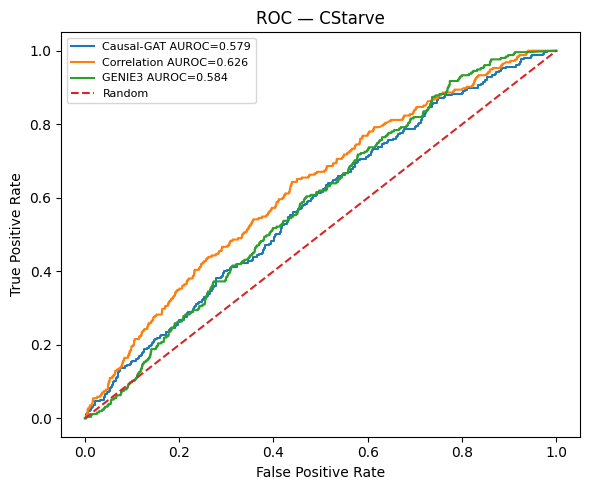

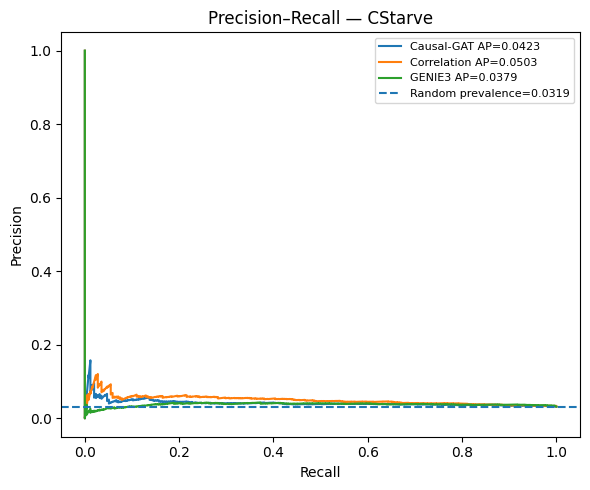

In [34]:

# =========================
# CELL 16 — Final figures with honest axes
# =========================
# Main seed comparison: same candidate space for all models.
if gold is not None:
    rows = []

    for env in TARGET_ENVS:
        S = np.load(OUT_DIR / f"causal_score_tf_{env}_seed{SEED}.npy")
        if "Correlation" in baseline_scores.get(env, {}):
            r, _ = benchmark_tf_score(
                baseline_scores[env]["Correlation"],
                genes, eval_tfs, gold, top_k=K, name="Correlation"
            )
            r["environment"] = env
            rows.append(r)

        if "GENIE3" in baseline_scores.get(env, {}):
            r, _ = benchmark_tf_score(
                baseline_scores[env]["GENIE3"],
                genes, eval_tfs, gold, top_k=K, name="GENIE3"
            )
            r["environment"] = env
            rows.append(r)

        r, _ = benchmark_tf_score(
            S, genes, eval_tfs, gold, top_k=K, name="Temporal Causal-GAT"
        )
        r["environment"] = env
        rows.append(r)

    final_comparison = pd.DataFrame(rows)
    final_comparison.to_csv(
        OUT_DIR / "FINAL_GSE125162_MODEL_COMPARISON.csv",
        index=False
    )

    print("\nFINAL MAIN-SEED COMPARISON")
    print(final_comparison.to_string(index=False))

    # AUROC: fixed 0-1 scale.
    plt.figure(figsize=(11,6))
    ax = sns.barplot(
        data=final_comparison,
        x="environment",
        y="AUROC",
        hue="model"
    )
    plt.ylim(0,1)
    plt.ylabel("AUROC")
    plt.xlabel("Environment")
    plt.title("AUROC — identical TF × target candidate space")
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.annotate(
                f"{h:.3f}",
                (p.get_x()+p.get_width()/2, h),
                ha="center", va="bottom",
                fontsize=8,
                xytext=(0,3),
                textcoords="offset points"
            )
    plt.tight_layout()
    plt.savefig(OUT_DIR / "FINAL_AUROC_comparison.png", dpi=300)
    plt.show()

    # AUPRC: fixed 0-1 scale plus prevalence line.
    plt.figure(figsize=(11,6))
    ax = sns.barplot(
        data=final_comparison,
        x="environment",
        y="AUPRC",
        hue="model"
    )
    plt.ylim(0,1)
    prevalence = K / max(len(eval_tfs)*len(genes)-len(eval_tfs),1)
    plt.axhline(
        prevalence,
        linestyle="--",
        linewidth=1.5,
        label=f"Random baseline = prevalence ({prevalence:.4f})"
    )
    plt.ylabel("Average Precision (PR-based)")
    plt.xlabel("Environment")
    plt.title("Average Precision — identical TF × target candidate space")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "FINAL_AUPRC_comparison.png", dpi=300)
    plt.show()

    # Multi-seed plot if available.
    if isinstance(all_seed_eval, pd.DataFrame) and len(all_seed_eval):
        rs = (
            all_seed_eval
            .groupby(["environment","model"], as_index=False)
            .agg(AUROC_mean=("AUROC","mean"), AUROC_sd=("AUROC","std"))
        )

        plt.figure(figsize=(11,6))
        ax = sns.barplot(
            data=rs,
            x="environment",
            y="AUROC_mean",
            hue="model",
            errorbar=None
        )
        # Error bars manually to make the SD explicit.
        for container, (_, sub) in zip(ax.containers, rs.groupby("model", sort=False)):
            pass

        plt.ylim(0,1)
        plt.ylabel("AUROC mean")
        plt.xlabel("Environment")
        plt.title("AUROC across seeds — mean ± SD reported in CSV")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "AUROC_multi_seed_mean.png", dpi=300)
        plt.show()

    # ROC / PR for main seed.
    for env in TARGET_ENVS:
        S = np.load(OUT_DIR / f"causal_score_tf_{env}_seed{SEED}.npy")
        y_c, s_c = curves_from_scores(S, genes, eval_tfs, gold)

        plt.figure(figsize=(6,5))
        if len(np.unique(y_c)) == 2:
            fpr,tpr,_ = roc_curve(y_c,s_c)
            plt.plot(fpr,tpr,label=f"Causal-GAT AUROC={roc_auc_score(y_c,s_c):.3f}")
        if "Correlation" in baseline_scores.get(env, {}):
            y_b,s_b = curves_from_scores(
                baseline_scores[env]["Correlation"], genes, eval_tfs, gold
            )
            fpr,tpr,_ = roc_curve(y_b,s_b)
            plt.plot(fpr,tpr,label=f"Correlation AUROC={roc_auc_score(y_b,s_b):.3f}")
        if "GENIE3" in baseline_scores.get(env, {}):
            y_g,s_g = curves_from_scores(
                baseline_scores[env]["GENIE3"], genes, eval_tfs, gold
            )
            fpr,tpr,_ = roc_curve(y_g,s_g)
            plt.plot(fpr,tpr,label=f"GENIE3 AUROC={roc_auc_score(y_g,s_g):.3f}")
        plt.plot([0,1],[0,1],"--",label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC — {env}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"ROC_{env}.png", dpi=250)
        plt.show()

        plt.figure(figsize=(6,5))
        if len(np.unique(y_c)) == 2:
            p,r,_ = precision_recall_curve(y_c,s_c)
            plt.plot(r,p,label=f"Causal-GAT AP={average_precision_score(y_c,s_c):.4f}")
        if "Correlation" in baseline_scores.get(env, {}):
            y_b,s_b = curves_from_scores(
                baseline_scores[env]["Correlation"], genes, eval_tfs, gold
            )
            p,r,_ = precision_recall_curve(y_b,s_b)
            plt.plot(r,p,label=f"Correlation AP={average_precision_score(y_b,s_b):.4f}")
        if "GENIE3" in baseline_scores.get(env, {}):
            y_g,s_g = curves_from_scores(
                baseline_scores[env]["GENIE3"], genes, eval_tfs, gold
            )
            p,r,_ = precision_recall_curve(y_g,s_g)
            plt.plot(r,p,label=f"GENIE3 AP={average_precision_score(y_g,s_g):.4f}")
        plt.axhline(prevalence, linestyle="--", linewidth=1.5, label=f"Random prevalence={prevalence:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision–Recall — {env}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"PR_{env}.png", dpi=250)
        plt.show()

else:
    print("No YEASTRACT gold standard: final benchmark plots skipped.")


In [35]:

# =========================
# CELL 17 — Coverage + save final AnnData + manifest
# =========================
coverage_rows = []

if gold is not None:
    gold_genes = set(gold["source"]) | set(gold["target"])
    gold_edges_in_model = gold[
        gold["source"].isin(model_gene_set) &
        gold["target"].isin(model_gene_set)
    ]

    gold_edges_in_candidate = gold[
        gold["source"].isin(eval_tfs) &
        gold["target"].isin(model_gene_set)
    ]

    coverage_rows.append({
        "benchmark": "YEASTRACT",
        "model_genes": len(genes),
        "gold_genes_total": len(gold_genes),
        "gold_genes_in_model": len(gold_genes & model_gene_set),
        "gold_gene_coverage": len(gold_genes & model_gene_set) / max(len(gold_genes),1),
        "gold_edges_total": len(gold),
        "gold_edges_in_model": len(gold_edges_in_model),
        "gold_edge_coverage": len(gold_edges_in_model) / max(len(gold),1),
        "candidate_TFs": len(eval_tfs),
        "candidate_edges": len(eval_tfs) * len(genes) - len(eval_tfs),
        "gold_positives_in_candidate_space": len(gold_edges_in_candidate),
        "TF_universe_source": TF_UNIVERSE_SOURCE
    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df.to_csv(OUT_DIR / "candidate_gold_coverage.csv", index=False)

adata_model.obs["relative_pseudotime"] = adata_model.obs["relative_pseudotime"].astype(float)
adata_model.write(OUT_DIR / "GSE125162_processed_model_v5.h5ad")
pd.DataFrame({"gene": genes}).to_csv(OUT_DIR / "final_gene_set.csv", index=False)
pd.DataFrame({"TF": eval_tfs}).to_csv(OUT_DIR / "evaluation_TF_universe.csv", index=False)

manifest = {
    "seed_main": SEED,
    "robustness_seeds": ROBUSTNESS_SEEDS,
    "n_hvg": N_HVG,
    "hidden": HIDDEN,
    "batch_size": BATCH_SIZE,
    "train_max_cells_per_env": TRAIN_MAX_CELLS_PER_ENV,
    "infer_cell_chunk": INFER_CELL_CHUNK,
    "temporal_gamma": TEMPORAL_GAMMA,
    "grad_weight": GRAD_WEIGHT,
    "ablation_weight": ABLATION_WEIGHT,
    "dag_outer_steps": DAG_OUTER_STEPS,
    "epochs_per_dag_step": EPOCHS_PER_DAG_STEP,
    "tf_universe_source": TF_UNIVERSE_SOURCE,
    "n_TFs": len(eval_tfs),
    "n_genes": len(genes),
    "device": str(DEVICE),
    "notes": [
        "Per-environment relative DPT; no shared cross-condition pseudotime.",
        "Shared model trained jointly across environments.",
        "No GRU over arbitrary gene order.",
        "Jacobian/ablation inference restricted to TF candidate sources.",
        "Ablation is standardized-input perturbation, not biological knockout.",
        "Observational data do not by themselves establish causal identification."
    ]
}
pd.Series(manifest).to_json(OUT_DIR / "run_manifest.json", force_ascii=False, indent=2)

print("\n" + "="*70)
print("PIPELINE COMPLETE")
print("="*70)
print("Results:", OUT_DIR)
if len(coverage_df):
    print("\nCoverage:")
    print(coverage_df.to_string(index=False))

print("\nFiles to use for thesis:")
for p in [
    "FINAL_GSE125162_MODEL_COMPARISON.csv",
    "robustness_mean_sd.csv",
    "candidate_gold_coverage.csv",
    "candidate_space_manifest.csv",
    "FINAL_AUROC_comparison.png",
    "FINAL_AUPRC_comparison.png"
]:
    print(" -", p)



PIPELINE COMPLETE
Results: output

Coverage:
benchmark  model_genes  gold_genes_total  gold_genes_in_model  gold_gene_coverage  gold_edges_total  gold_edges_in_model  gold_edge_coverage  candidate_TFs  candidate_edges  gold_positives_in_candidate_space TF_universe_source
YEASTRACT          500              4038                  370             0.09163             26528                  255            0.009612             16             7984                                255   oracle_from_gold

Files to use for thesis:
 - FINAL_GSE125162_MODEL_COMPARISON.csv
 - robustness_mean_sd.csv
 - candidate_gold_coverage.csv
 - candidate_space_manifest.csv
 - FINAL_AUROC_comparison.png
 - FINAL_AUPRC_comparison.png


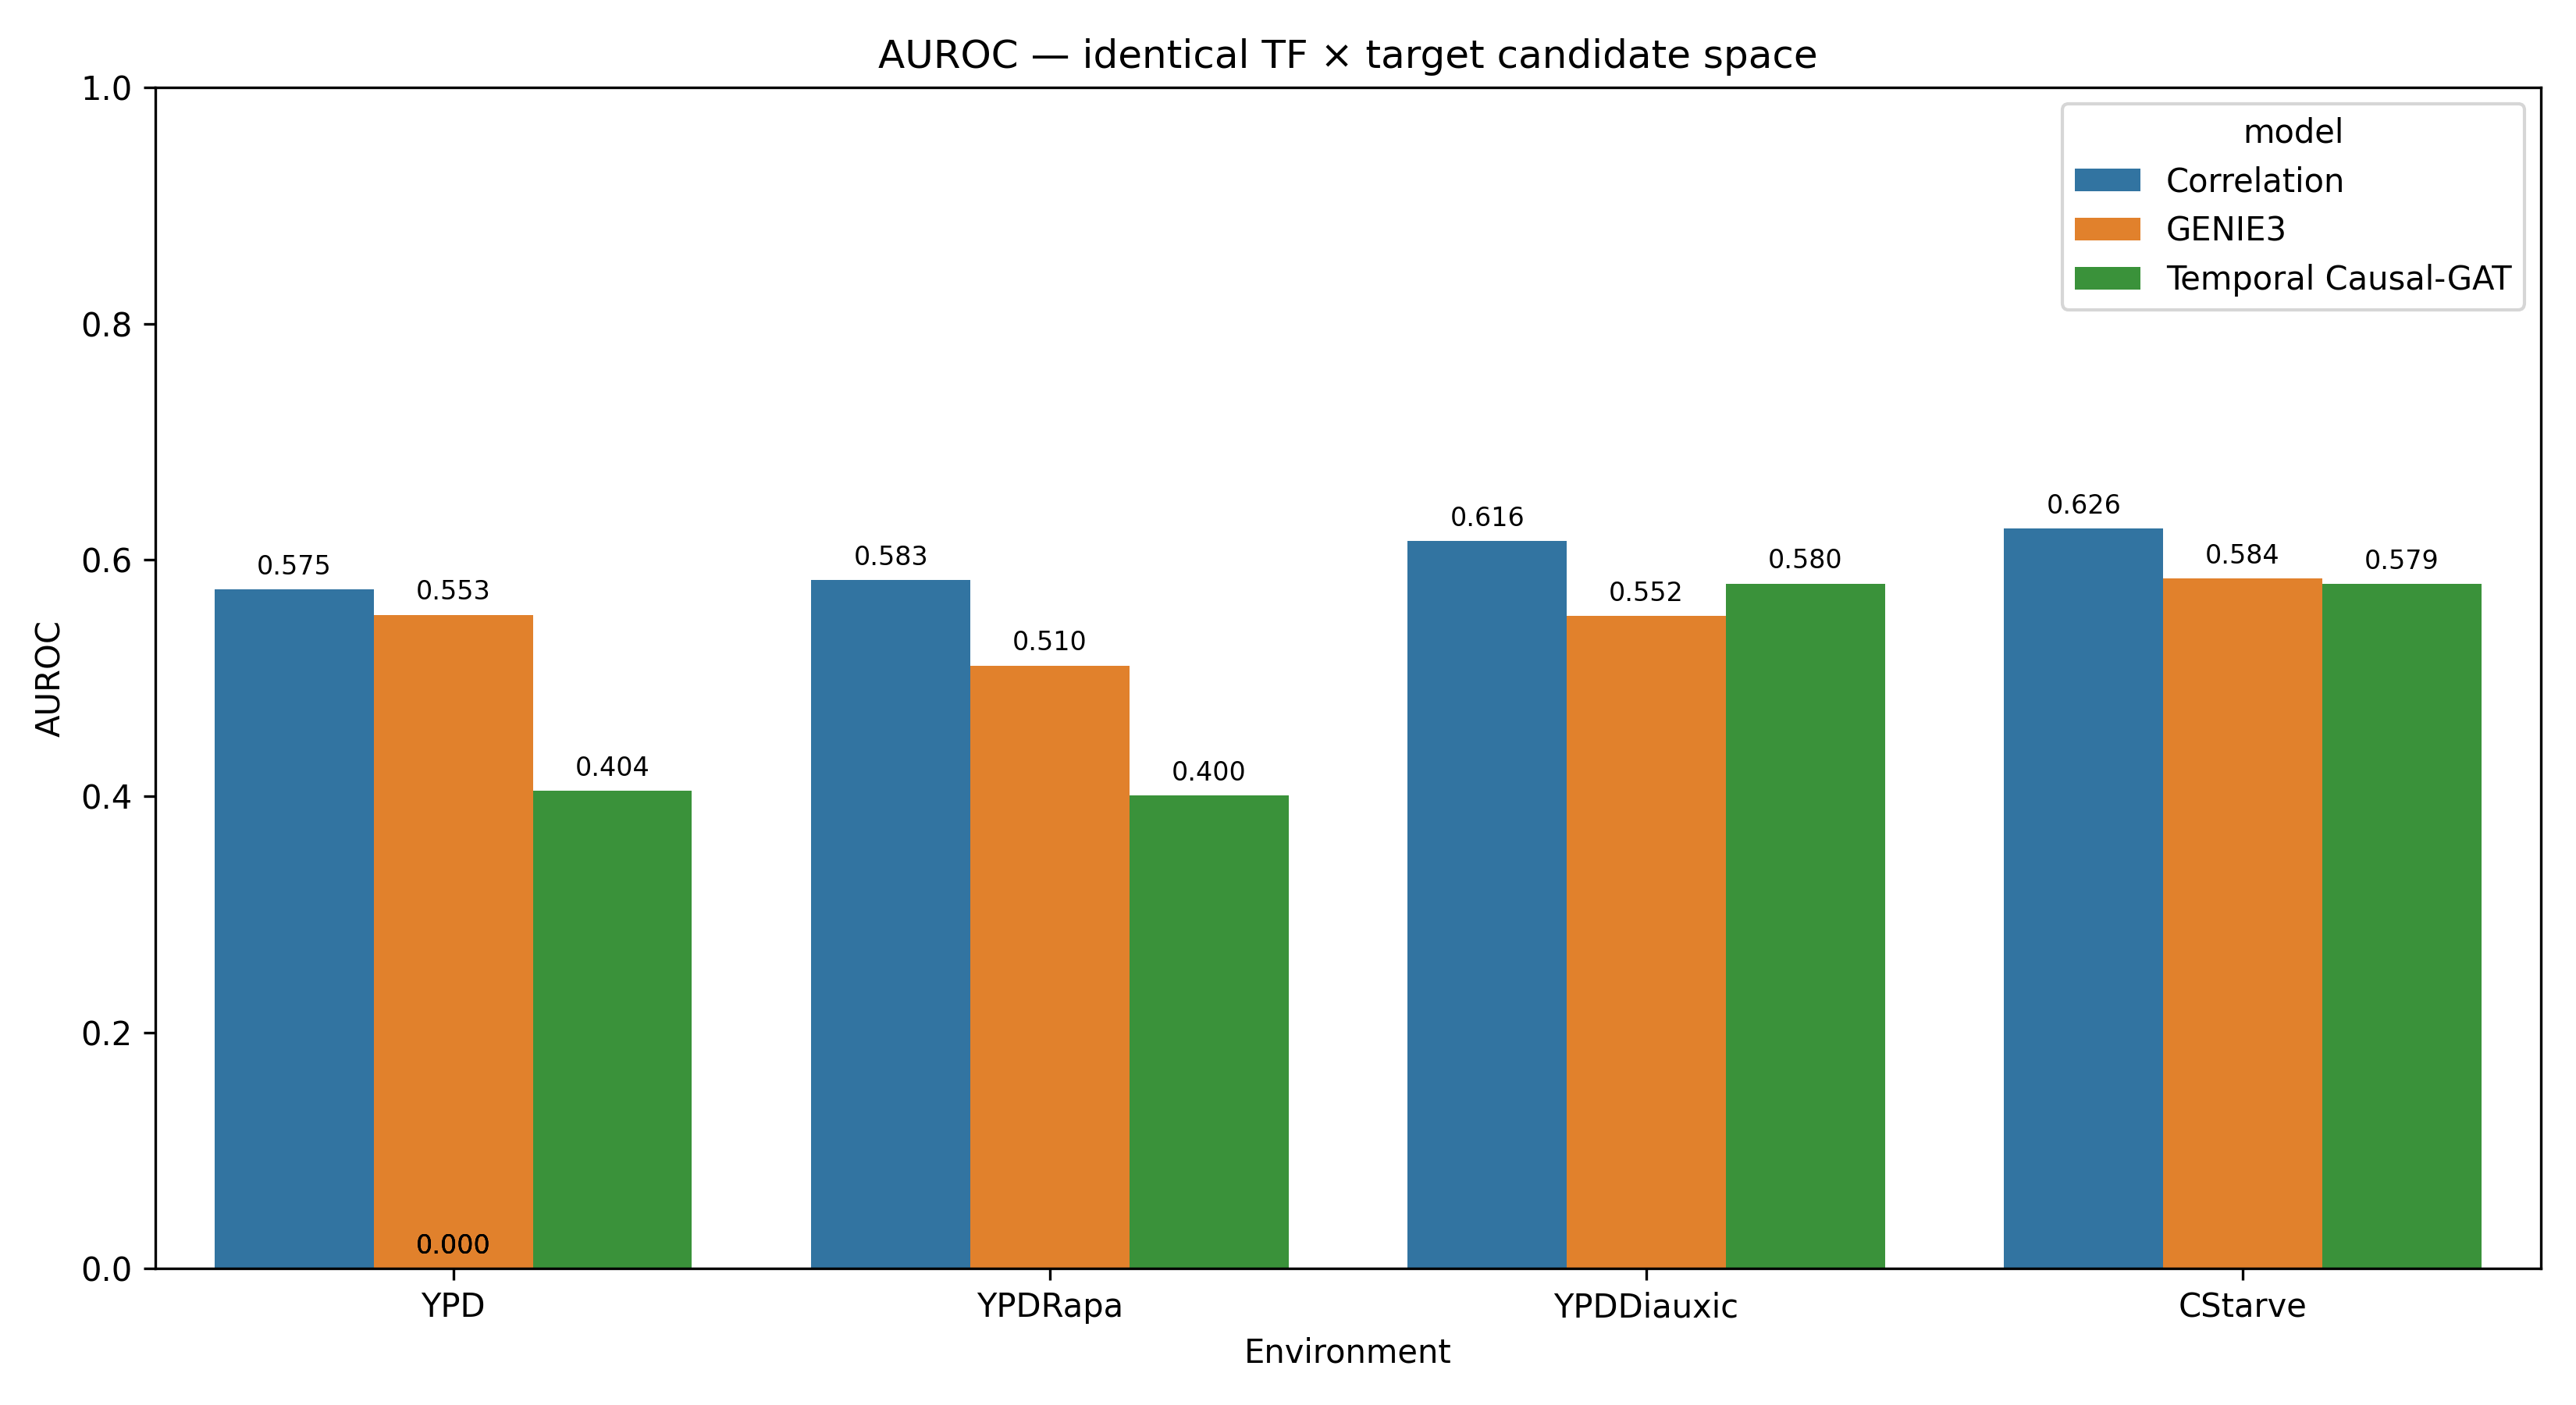

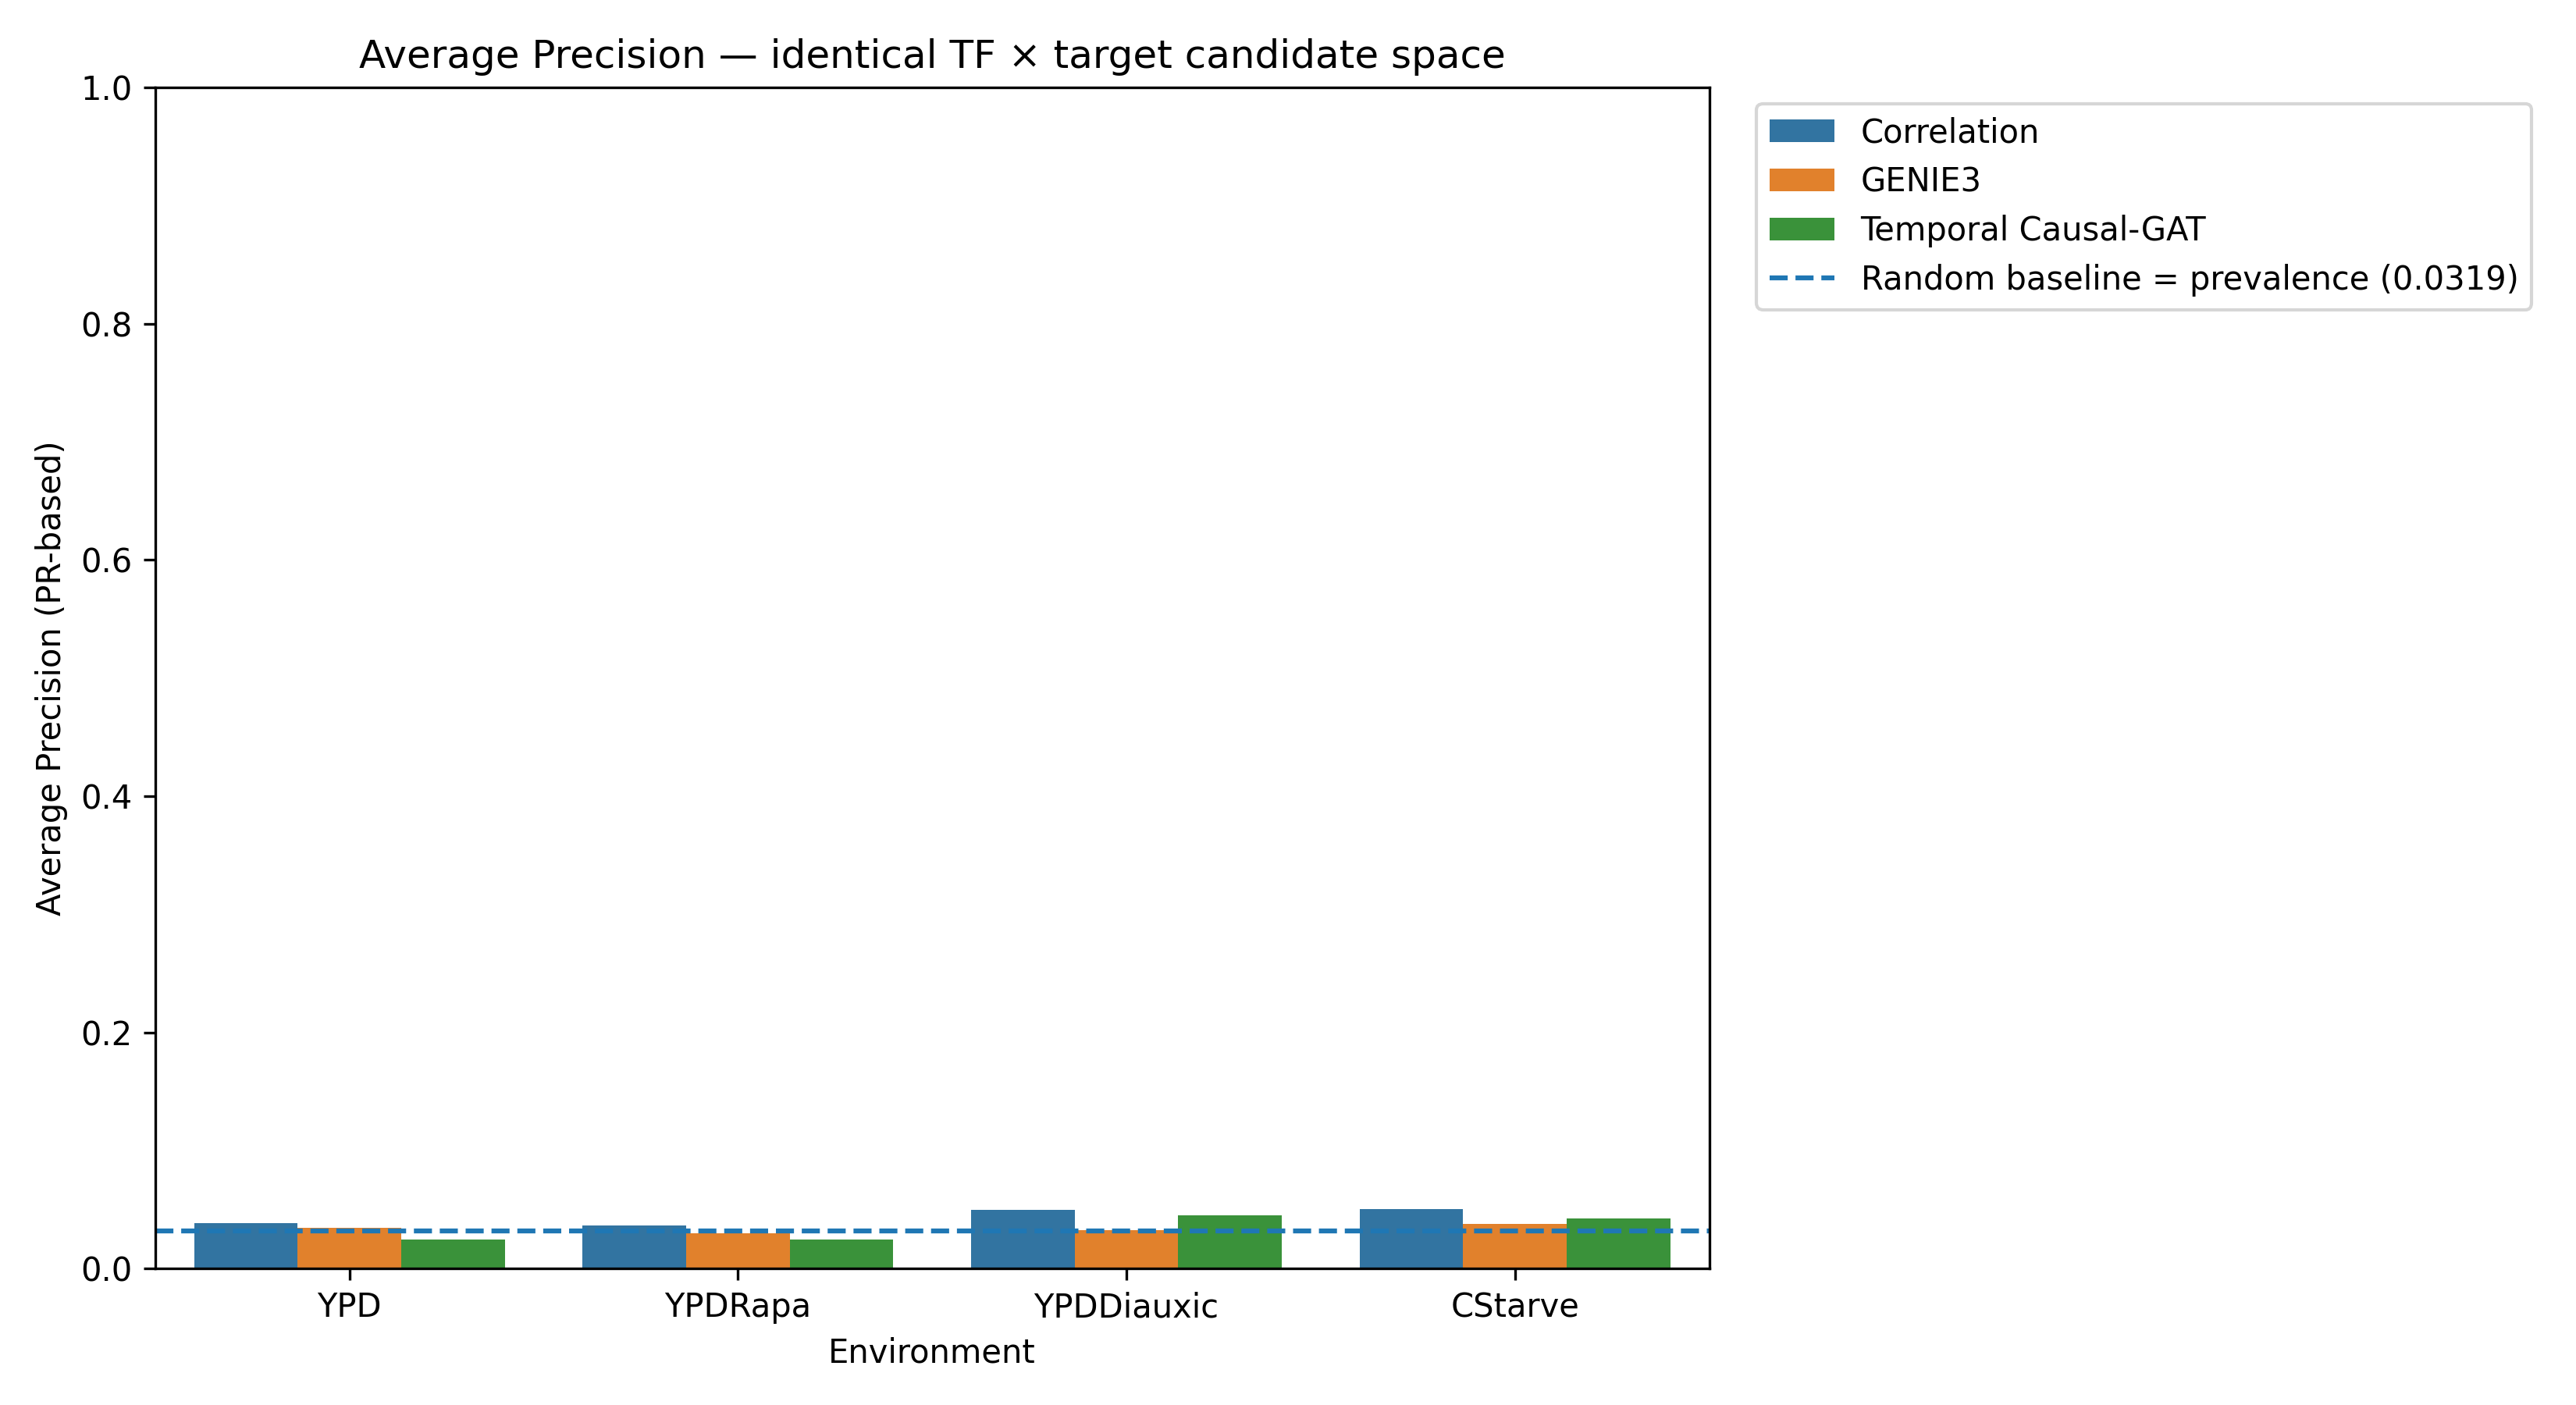

In [37]:
from IPython.display import display, Image
display(Image("output/FINAL_AUROC_comparison.png"))
display(Image("output/FINAL_AUPRC_comparison.png"))